### 热销产品的销售总金额预测

### Connect postgresql database

In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text

# 数据库配置
username = "XXXXXX"
password = "YYYYYY"
host = "localhost"
port = 5432
database = "eyewear-data"

# 创建连接
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)


### Query and cal customer RFM feature

In [3]:
# 1 . 每月销售额、订单数量和平均订单价值
sale_amount_monthly_sql = """
WITH product_region_monthly_quantity AS (
    SELECT
        TO_CHAR(o.order_date,'YYYY-MM') AS order_month,
        p.product_id,c.region,
        SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) AS region_paid_quantity
    FROM "Order" o
    JOIN "OrderItem" oi ON o.order_id = oi.order_id
    LEFT JOIN "CustomerInfo" c ON o.customer_id = c.customer_id
    LEFT JOIN "ProductInfo" p  ON oi.product_id = p.product_id
    WHERE o.order_status IN ('Completed','Shipped')
      AND o.order_date IS NOT NULL
    GROUP BY TO_CHAR(o.order_date,'YYYY-MM'), p.product_id,c.region
),

-- 地区集中度（基于销量）
product_region_rank AS (
    SELECT *,
           RANK() OVER(PARTITION BY order_month,product_id ORDER BY region_paid_quantity DESC) AS product_region_rank
    FROM product_region_monthly_quantity   -- ← 这里修正：改成 product_region_monthly_quantity
),

product_region_concentration AS (
    SELECT
        order_month,product_id,
        MAX(CASE WHEN product_region_rank = 1 THEN region_paid_quantity END)::numeric 
            / NULLIF(SUM(region_paid_quantity)::numeric, 0) AS top_region_quantity_ratio,
        SUM(CASE WHEN product_region_rank <=5 THEN region_paid_quantity ELSE 0 END)::numeric 
            / NULLIF(SUM(region_paid_quantity)::numeric, 0) AS top5_region_quantity_ratio
    FROM product_region_rank
    GROUP BY order_month,product_id
),

product_region_entropy AS (
    SELECT
        order_month,product_id,
        -SUM(qty_share * LN(qty_share)) AS region_paid_qty_entropy
    FROM (
        SELECT
            order_month,
            product_id,
            region,
            region_paid_quantity::numeric / NULLIF(SUM(region_paid_quantity::numeric) OVER (PARTITION BY order_month, product_id), 0) AS qty_share
        FROM product_region_monthly_quantity   -- ← 这里也要修正
    ) t
    GROUP BY order_month,product_id
)

SELECT
    to_char(o.order_date, 'YYYY-MM') AS order_month,
    -- 基础指标
    p.product_id,
    p.category,
    COUNT(DISTINCT o.order_id) AS order_count,
    COUNT(DISTINCT o.customer_id) AS unique_customer_count,

    SUM(oi.line_price_after_tax) AS monthly_revenue,
    SUM(oi.line_price_before_tax) AS monthly_revenue_before_tax,
    SUM(o.total_price_after_tax)/COUNT(DISTINCT o.order_id) AS avg_order_value,

    -- 目标变量
    SUM(oi.quantity) AS total_quantity,   
    SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) AS customer_paid_quantity, -- ← 预测目标
    
    -- 每个订单平均付费商品数量（推荐）
    SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS avg_paid_qty_per_order,

    -- 每个订单平均总商品数量（包含赠品）
    SUM(oi.quantity)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS avg_total_qty_per_order,

    -- 价格
    SUM(oi.line_price_after_tax)/NULLIF(SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END),0) 
        AS avg_unit_price,

    -- 促销
    COUNT(DISTINCT pa.campaign_id) AS promotion_count,
    COUNT(DISTINCT CASE WHEN o.campaign_id IS NOT NULL THEN o.order_id END) AS promo_order_count,
    -- 促销订单占比（按订单）
    COUNT(DISTINCT CASE WHEN o.campaign_id IS NOT NULL THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS promo_order_ratio,
    
    -- 促销贡献的付费销量占比（推荐使用这个）
    SUM(CASE WHEN o.campaign_id IS NOT NULL 
             THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END)
             ELSE 0 END)::numeric 
        / NULLIF(SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END), 0) 
        AS promo_paid_qty_ratio,

    -- 促销贡献的总销量占比（作为对比）
    SUM(CASE WHEN o.campaign_id IS NOT NULL THEN oi.quantity ELSE 0 END)::numeric 
        / NULLIF(SUM(oi.quantity), 0) AS promo_total_qty_ratio,
    
        
    AVG(CASE WHEN pa.discount_type='Percentage' THEN pa.discount_value END) AS avg_percentage_discount,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Percentage' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS percentage_discount_order_ratio,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Fixed Amount' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS fixed_amount_discount_order_ratio,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Free Gift' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS free_gift_order_ratio,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Buy One Get One' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS bogo_order_ratio,

    -- 地区
    MAX(rc.top_region_quantity_ratio) AS top_region_quantity_ratio,
    MAX(rc.top5_region_quantity_ratio) AS top5_region_quantity_ratio,
    MAX(re.region_paid_qty_entropy) AS region_paid_qty_entropy,

    -- 产品结构（已使用quantity）
    SUM(CASE WHEN p.category = 'Eyeglasses' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_eyeglasses,

    SUM(CASE WHEN p.category = 'Sunglasses' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_sunglass,

    SUM(CASE WHEN p.category = 'AI Glasses' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_ai_glasses,

    SUM(CASE WHEN p.category = 'Lens' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_lens,

    -- 时间特征
    EXTRACT(YEAR FROM o.order_date) AS year,
    EXTRACT(MONTH FROM o.order_date) AS month,
    CONCAT(EXTRACT(YEAR FROM o.order_date),'-Q',EXTRACT(QUARTER FROM o.order_date)::int) AS quarter,
    CASE 
        WHEN EXTRACT(MONTH FROM o.order_date) IN (12,1,2) THEN 'Winter'
        WHEN EXTRACT(MONTH FROM o.order_date) IN (3,4,5) THEN 'Spring'
        WHEN EXTRACT(MONTH FROM o.order_date) IN (6,7,8) THEN 'Summer'
        ELSE 'Autumn' 
    END AS season

FROM "Order" o
JOIN "OrderItem" oi ON o.order_id = oi.order_id
LEFT JOIN "PromotionActivity" pa ON o.campaign_id = pa.campaign_id
LEFT JOIN "CustomerInfo" c ON o.customer_id = c.customer_id
LEFT JOIN "ProductInfo" p ON oi.product_id = p.product_id
LEFT JOIN product_region_concentration rc ON rc.order_month = TO_CHAR(o.order_date,'YYYY-MM') AND
rc.product_id = p.product_id
LEFT JOIN product_region_entropy re ON re.order_month = TO_CHAR(o.order_date,'YYYY-MM')
AND re.product_id=p.product_id
WHERE o.order_status IN ('Completed', 'Shipped')
  AND o.order_date IS NOT NULL
  AND p.category <> 'Accessory'

GROUP BY
  to_char(o.order_date, 'YYYY-MM'),
  p.product_id,
  p.category,
  EXTRACT(YEAR FROM o.order_date),
  EXTRACT(MONTH FROM o.order_date),
  EXTRACT(QUARTER FROM o.order_date),
  CASE 
    WHEN EXTRACT(MONTH FROM o.order_date) IN (12,1,2) THEN 'Winter'
    WHEN EXTRACT(MONTH FROM o.order_date) IN (3,4,5) THEN 'Spring'
    WHEN EXTRACT(MONTH FROM o.order_date) IN (6,7,8) THEN 'Summer'
    ELSE 'Autumn' 
  END
"""

df_sale_amount_monthly = pd.read_sql(sale_amount_monthly_sql, engine)

df_sale_amount_monthly

,order_month,product_id,category,order_count,unique_customer_count,monthly_revenue,monthly_revenue_before_tax,avg_order_value,total_quantity,customer_paid_quantity,...,top5_region_quantity_ratio,region_paid_qty_entropy,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,year,month,quarter,season
0,2023-01,1,Sunglasses,159,159,29176.93,26645.64,435.504340,167,167,...,0.724551,2.282651,0,167,0,0,2023.0,1.0,2023-Q1,Winter
1,2023-01,2,Eyeglasses,139,139,37594.24,34332.44,553.970647,148,148,...,0.756757,2.262942,148,0,0,0,2023.0,1.0,2023-Q1,Winter
2,2023-01,3,AI Glasses,53,53,14236.48,13001.28,559.400755,59,59,...,0.694915,2.261456,0,0,59,0,2023.0,1.0,2023-Q1,Winter
3,2023-01,4,AI Glasses,49,49,16397.03,14974.32,605.038776,53,53,...,0.698113,2.320953,0,0,53,0,2023.0,1.0,2023-Q1,Winter
4,2023-01,5,Eyeglasses,118,118,67513.19,61655.77,815.581186,133,133,...,0.706767,2.351227,133,0,0,0,2023.0,1.0,2023-Q1,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,2024-12,196,Lens,86,86,29969.58,27369.42,588.643605,94,94,...,0.819149,2.156786,0,0,0,94,2024.0,12.0,2024-Q4,Winter
4796,2024-12,197,Lens,70,70,20420.52,18648.70,599.421286,73,73,...,0.671233,2.270118,0,0,0,73,2024.0,12.0,2024-Q4,Winter
4797,2024-12,198,Lens,77,77,10872.59,9929.15,435.239091,91,91,...,0.736264,2.270461,0,0,0,91,2024.0,12.0,2024-Q4,Winter
4798,2024-12,199,Lens,86,86,24868.02,22710.79,544.370581,93,93,...,0.666667,2.426355,0,0,0,93,2024.0,12.0,2024-Q4,Winter


In [4]:
df_sale_amount_monthly['category'].unique()

array(['Sunglasses', 'Eyeglasses', 'AI Glasses', 'Lens'], dtype=object)

In [5]:
df_sale_amount_monthly.columns

Index(['order_month', 'product_id', 'category', 'order_count',
       'unique_customer_count', 'monthly_revenue',
       'monthly_revenue_before_tax', 'avg_order_value', 'total_quantity',
       'customer_paid_quantity', 'avg_paid_qty_per_order',
       'avg_total_qty_per_order', 'avg_unit_price', 'promotion_count',
       'promo_order_count', 'promo_order_ratio', 'promo_paid_qty_ratio',
       'promo_total_qty_ratio', 'avg_percentage_discount',
       'percentage_discount_order_ratio', 'fixed_amount_discount_order_ratio',
       'free_gift_order_ratio', 'bogo_order_ratio',
       'top_region_quantity_ratio', 'top5_region_quantity_ratio',
       'region_paid_qty_entropy', 'paid_qty_eyeglasses', 'paid_qty_sunglass',
       'paid_qty_ai_glasses', 'paid_qty_lens', 'year', 'month', 'quarter',
       'season'],
      dtype='object')

### Define and identify best-selling products

In [ ]:
# 热销定义：按历史付费销量 或 销售额 排名
# 建议只用训练集时间段选 Top-N，避免用到测试期信息（更严谨）
TOP_N = 20
# 可以根据需求选择按销售金额或销售数量来排名
RANK_BY = "revenue" 

popular_product_sql = f"""
WITH product_stats AS (
    SELECT
        oi.product_id,
        COALESCE(p.product_name, oi.product_name) AS product_name,
        p.category,
        p.brand,
        SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) AS paid_qty,
        SUM(oi.line_price_after_tax) AS revenue
    FROM "Order" o
    JOIN "OrderItem" oi ON o.order_id = oi.order_id
    LEFT JOIN "ProductInfo" p ON oi.product_id = p.product_id
    WHERE o.order_status IN ('Completed', 'Shipped')
      AND o.order_date IS NOT NULL
      -- 更严谨：只用训练期，例如 2024-06 及以前
      -- AND to_char(o.order_date, 'YYYY-MM') < '2024-07-01'
      AND p.category <> 'Accessory'
    GROUP BY oi.product_id, COALESCE(p.product_name, oi.product_name), p.category, p.brand
)
SELECT *
FROM product_stats
ORDER BY {"revenue" if RANK_BY == "revenue" else "paid_qty"} DESC
LIMIT {TOP_N}
"""

df_popular = pd.read_sql(popular_product_sql, engine)
popular_ids = df_popular["product_id"].tolist()
df_popular

,product_id,product_name,category,brand,paid_qty,revenue
0,103,Ray-Ban Ray-Ban Reverse Non-prescription,AI Glasses,Ray-Ban,5401,3472309.89
1,92,Ray-Ban Ray-Ban Meta Prescription,AI Glasses,Ray-Ban,5375,2915955.19
2,111,Ray-Ban Ray-Ban Meta Non-prescription,AI Glasses,Ray-Ban,5477,2618577.94
3,102,Ray-Ban Ray-Ban Reverse Prescription,AI Glasses,Ray-Ban,5370,2491675.78
4,107,Ray-Ban Ray-Ban Reverse Prescription,AI Glasses,Ray-Ban,5405,2397691.26
5,43,Ray-Ban Ray-Ban Reverse Non-prescription,AI Glasses,Ray-Ban,5506,2390265.78
6,30,Ray-Ban Ray-Ban Meta Non-prescription,AI Glasses,Ray-Ban,5387,2388773.77
7,9,Ray-Ban Ray-Ban Reverse Non-prescription,AI Glasses,Ray-Ban,5434,2363335.11
8,42,Ray-Ban Ray-Ban Reverse Non-prescription,AI Glasses,Ray-Ban,5367,2261448.08
9,32,Ray-Ban Ray-Ban Meta Prescription,AI Glasses,Ray-Ban,5394,2197883.35


### choose popular product dataset

In [ ]:
# 热销产品ID: [103, 92, 111, 102, 107, 43, 30, 9, 42, 32, 11, 58, 48, 7, 94, 77, 134, 99, 69, 44]
# 筛选出df_sale_amount_monthly的product_id满足热销产品ID:的子集
df_sale_amount_monthly_popular = df_sale_amount_monthly[df_sale_amount_monthly["product_id"].isin(popular_ids)]
df_sale_amount_monthly_popular

,order_month,product_id,category,order_count,unique_customer_count,monthly_revenue,monthly_revenue_before_tax,avg_order_value,total_quantity,customer_paid_quantity,...,top5_region_quantity_ratio,region_paid_qty_entropy,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,year,month,quarter,season
6,2023-01,7,AI Glasses,54,54,21819.17,19926.33,640.883333,62,62,...,0.838710,2.226906,0,0,62,0,2023.0,1.0,2023-Q1,Winter
8,2023-01,9,AI Glasses,50,50,23743.10,21683.20,661.090600,53,53,...,0.886792,2.021312,0,0,53,0,2023.0,1.0,2023-Q1,Winter
10,2023-01,11,Sunglasses,154,154,99843.59,91181.07,942.009935,167,167,...,0.670659,2.424018,0,167,0,0,2023.0,1.0,2023-Q1,Winter
29,2023-01,30,AI Glasses,58,58,27223.95,24862.01,704.005000,62,62,...,0.774194,2.129738,0,0,62,0,2023.0,1.0,2023-Q1,Winter
31,2023-01,32,AI Glasses,58,58,28169.48,25725.47,713.584310,67,67,...,0.671642,2.320495,0,0,67,0,2023.0,1.0,2023-Q1,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4701,2024-12,102,AI Glasses,354,354,171753.71,156852.65,772.755791,381,381,...,0.677165,2.406283,0,0,381,0,2024.0,12.0,2024-Q4,Winter
4702,2024-12,103,AI Glasses,375,374,274368.16,250564.71,975.350587,439,439,...,0.708428,2.306305,0,0,439,0,2024.0,12.0,2024-Q4,Winter
4706,2024-12,107,AI Glasses,358,358,174632.93,159481.78,787.109832,404,404,...,0.722772,2.343964,0,0,404,0,2024.0,12.0,2024-Q4,Winter
4710,2024-12,111,AI Glasses,372,370,185093.92,169035.64,726.757984,402,402,...,0.689055,2.363293,0,0,402,0,2024.0,12.0,2024-Q4,Winter


In [8]:
df_sale_amount_monthly_popular.columns

Index(['order_month', 'product_id', 'category', 'order_count',
       'unique_customer_count', 'monthly_revenue',
       'monthly_revenue_before_tax', 'avg_order_value', 'total_quantity',
       'customer_paid_quantity', 'avg_paid_qty_per_order',
       'avg_total_qty_per_order', 'avg_unit_price', 'promotion_count',
       'promo_order_count', 'promo_order_ratio', 'promo_paid_qty_ratio',
       'promo_total_qty_ratio', 'avg_percentage_discount',
       'percentage_discount_order_ratio', 'fixed_amount_discount_order_ratio',
       'free_gift_order_ratio', 'bogo_order_ratio',
       'top_region_quantity_ratio', 'top5_region_quantity_ratio',
       'region_paid_qty_entropy', 'paid_qty_eyeglasses', 'paid_qty_sunglass',
       'paid_qty_ai_glasses', 'paid_qty_lens', 'year', 'month', 'quarter',
       'season'],
      dtype='object')

### cal timeseries feature for sale amount(针对热销产品预测销售数量)

In [10]:
import numpy as np
df_timeseries_features = (
    df_sale_amount_monthly_popular[
        ["order_month","product_id", "monthly_revenue","order_count","unique_customer_count"]
    ]
    .sort_values(["order_month","product_id"])
    .copy()
)

df_timeseries_features["trend"] = (
    df_timeseries_features
    .groupby("product_id")
    .cumcount()
)


# 基础时间序列特征
for lag in [1, 2, 3, 4, 12]:
    df_timeseries_features[f"lag_{lag}_month_revenue"] = (
        df_timeseries_features
        .groupby("product_id")["monthly_revenue"]
        .shift(lag)
    )

# 计算滚动平均值
df_timeseries_features["rolling_3_month_avg_revenue"] = (
    df_timeseries_features
    .groupby("product_id")["monthly_revenue"]
    .shift(1)
    .rolling(3)
    .mean()
)
df_timeseries_features["rolling_6_month_avg_revenue"] = (
    df_timeseries_features
    .groupby("product_id")["monthly_revenue"]
    .shift(1)
    .rolling(6)
    .mean()
)
df_timeseries_features["rolling_12_month_avg_revenue"] = (
    df_timeseries_features
    .groupby("product_id")["monthly_revenue"]
    .shift(1)
    .rolling(12)
    .mean()
)


# ==================== 新增的3种 Baseline ====================

# 1. Historical Mean（历史均值）
df_timeseries_features["historical_mean"] = (
    df_timeseries_features
    .groupby("product_id")["monthly_revenue"]
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)
# 2. Historical Median（历史中位数 Baseline）
df_timeseries_features["historical_median"] = (
    df_timeseries_features
    .groupby("product_id")["monthly_revenue"]
    .expanding()
    .median()
    .reset_index(level=0, drop=True)
)

# 3. Weighted Moving Average (WMA - 线性加权移动平均)
def weighted_moving_average(x, window=3):
    """线性加权：最近的月份权重最高"""
    if len(x) < window:
        return np.nan
    weights = np.arange(1, window + 1)      # 如 window=3 时权重为 [1,2,3]
    return np.dot(x, weights) / weights.sum()

# 计算 WMA
df_timeseries_features["wma_3"] = (
    df_timeseries_features
    .groupby("product_id")["monthly_revenue"]
    .shift(1)
    .rolling(3)
    .apply(weighted_moving_average, raw=True)
)

# 指数加权移动平均
df_timeseries_features["ewm_3"] = (
    df_timeseries_features
    .groupby("product_id")["monthly_revenue"]
    .transform(lambda x: x.ewm(span=3,adjust=False).mean())
)

df_timeseries_features["ewm_6"] = (
    df_timeseries_features
    .groupby("product_id")["monthly_revenue"]
    .transform(lambda x: x.ewm(span=6,adjust=False).mean())
)

df_timeseries_features["ewm_alpha"] = (
    df_timeseries_features
    .groupby("product_id")["monthly_revenue"]
    .transform(lambda x: x.ewm(alpha=0.3,adjust=False).mean())
)

# Growth 特征
df_timeseries_features["mom_growth"] = (
    df_timeseries_features
    .groupby("product_id")["monthly_revenue"]
    .shift(1)
    .pct_change(1)
)

df_timeseries_features["yoy_growth"] = (
    df_timeseries_features
    .groupby("product_id")["monthly_revenue"]
    .shift(1)
    .pct_change(12)
)

# 加速/减速信号
df_timeseries_features["mom_acceleration"] = (
    df_timeseries_features["mom_growth"]
    -
    df_timeseries_features
    .groupby("product_id")["mom_growth"]
    .shift(1)
)

df_timeseries_features["lag_1_order_count"] = (
    df_timeseries_features
    .groupby("product_id")["order_count"]
    .shift(1)
)

df_timeseries_features["lag_1_customer_count"] = (
    df_timeseries_features
    .groupby("product_id")["unique_customer_count"]
    .shift(1)
)

df_timeseries_features

,order_month,product_id,monthly_revenue,order_count,unique_customer_count,trend,lag_1_month_revenue,lag_2_month_revenue,lag_3_month_revenue,lag_4_month_revenue,...,historical_median,wma_3,ewm_3,ewm_6,ewm_alpha,mom_growth,yoy_growth,mom_acceleration,lag_1_order_count,lag_1_customer_count
6,2023-01,7,21819.17,54,54,0,NaN,NaN,NaN,NaN,...,21819.170,NaN,21819.170000,21819.170000,21819.170000,NaN,NaN,NaN,NaN,NaN
8,2023-01,9,23743.10,50,50,0,NaN,NaN,NaN,NaN,...,23743.100,NaN,23743.100000,23743.100000,23743.100000,NaN,NaN,NaN,NaN,NaN
10,2023-01,11,99843.59,154,154,0,NaN,NaN,NaN,NaN,...,99843.590,NaN,99843.590000,99843.590000,99843.590000,NaN,NaN,NaN,NaN,NaN
29,2023-01,30,27223.95,58,58,0,NaN,NaN,NaN,NaN,...,27223.950,NaN,27223.950000,27223.950000,27223.950000,NaN,NaN,NaN,NaN,NaN
31,2023-01,32,28169.48,58,58,0,NaN,NaN,NaN,NaN,...,28169.480,NaN,28169.480000,28169.480000,28169.480000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4701,2024-12,102,171753.71,354,354,23,189506.72,206981.55,110652.43,111835.46,...,92436.170,153963.141667,173585.192250,160924.422269,162240.661565,0.334657,-0.052959,0.005403,383.0,383.0
4702,2024-12,103,274368.16,375,374,23,260577.36,301223.52,139350.97,155071.43,...,119932.960,217122.438333,258936.255801,232660.575795,235073.917027,0.375030,0.394246,-0.080286,385.0,385.0
4706,2024-12,107,174632.93,358,358,23,203998.76,198379.67,105851.35,111692.18,...,86109.970,220442.953333,176901.520701,161438.860412,162984.350633,-0.217128,0.139098,0.124293,416.0,415.0
4710,2024-12,111,185093.92,372,370,23,193692.91,217141.83,115660.94,125863.21,...,102013.225,208275.601667,183465.147516,169552.094278,170967.076159,-0.050519,-0.004911,-0.145096,376.0,376.0


In [11]:
df_timeseries_features.columns

Index(['order_month', 'product_id', 'monthly_revenue', 'order_count',
       'unique_customer_count', 'trend', 'lag_1_month_revenue',
       'lag_2_month_revenue', 'lag_3_month_revenue', 'lag_4_month_revenue',
       'lag_12_month_revenue', 'rolling_3_month_avg_revenue',
       'rolling_6_month_avg_revenue', 'rolling_12_month_avg_revenue',
       'historical_mean', 'historical_median', 'wma_3', 'ewm_3', 'ewm_6',
       'ewm_alpha', 'mom_growth', 'yoy_growth', 'mom_acceleration',
       'lag_1_order_count', 'lag_1_customer_count'],
      dtype='object')

### merge 2 dataframe

In [12]:
df_sale_amount_monthly_final = (
    df_sale_amount_monthly_popular
    .merge(
        df_timeseries_features[
            [
                "order_month",
                "product_id",
                "trend",
                "lag_1_month_revenue",
                "lag_2_month_revenue",
                "lag_3_month_revenue",
                "lag_4_month_revenue",
                "lag_12_month_revenue",
                "rolling_3_month_avg_revenue",
                "rolling_6_month_avg_revenue",
                "rolling_12_month_avg_revenue",
                "historical_mean", 
                "historical_median", 
                "wma_3",
                "ewm_3", 
                "ewm_6", 
                "ewm_alpha",
                "mom_growth",
                "yoy_growth",
                "mom_acceleration",
                "lag_1_order_count",
                "lag_1_customer_count"
            ]
        ],
        on=["order_month","product_id"],
        how="left"
    )
)

df_sale_amount_monthly_final

,order_month,product_id,category,order_count,unique_customer_count,monthly_revenue,monthly_revenue_before_tax,avg_order_value,total_quantity,customer_paid_quantity,...,historical_median,wma_3,ewm_3,ewm_6,ewm_alpha,mom_growth,yoy_growth,mom_acceleration,lag_1_order_count,lag_1_customer_count
0,2023-01,7,AI Glasses,54,54,21819.17,19926.33,640.883333,62,62,...,21819.170,NaN,21819.170000,21819.170000,21819.170000,NaN,NaN,NaN,NaN,NaN
1,2023-01,9,AI Glasses,50,50,23743.10,21683.20,661.090600,53,53,...,23743.100,NaN,23743.100000,23743.100000,23743.100000,NaN,NaN,NaN,NaN,NaN
2,2023-01,11,Sunglasses,154,154,99843.59,91181.07,942.009935,167,167,...,99843.590,NaN,99843.590000,99843.590000,99843.590000,NaN,NaN,NaN,NaN,NaN
3,2023-01,30,AI Glasses,58,58,27223.95,24862.01,704.005000,62,62,...,27223.950,NaN,27223.950000,27223.950000,27223.950000,NaN,NaN,NaN,NaN,NaN
4,2023-01,32,AI Glasses,58,58,28169.48,25725.47,713.584310,67,67,...,28169.480,NaN,28169.480000,28169.480000,28169.480000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,2024-12,102,AI Glasses,354,354,171753.71,156852.65,772.755791,381,381,...,92436.170,153963.141667,173585.192250,160924.422269,162240.661565,0.334657,-0.052959,0.005403,383.0,383.0
476,2024-12,103,AI Glasses,375,374,274368.16,250564.71,975.350587,439,439,...,119932.960,217122.438333,258936.255801,232660.575795,235073.917027,0.375030,0.394246,-0.080286,385.0,385.0
477,2024-12,107,AI Glasses,358,358,174632.93,159481.78,787.109832,404,404,...,86109.970,220442.953333,176901.520701,161438.860412,162984.350633,-0.217128,0.139098,0.124293,416.0,415.0
478,2024-12,111,AI Glasses,372,370,185093.92,169035.64,726.757984,402,402,...,102013.225,208275.601667,183465.147516,169552.094278,170967.076159,-0.050519,-0.004911,-0.145096,376.0,376.0


In [13]:
df_sale_amount_monthly_final.columns

Index(['order_month', 'product_id', 'category', 'order_count',
       'unique_customer_count', 'monthly_revenue',
       'monthly_revenue_before_tax', 'avg_order_value', 'total_quantity',
       'customer_paid_quantity', 'avg_paid_qty_per_order',
       'avg_total_qty_per_order', 'avg_unit_price', 'promotion_count',
       'promo_order_count', 'promo_order_ratio', 'promo_paid_qty_ratio',
       'promo_total_qty_ratio', 'avg_percentage_discount',
       'percentage_discount_order_ratio', 'fixed_amount_discount_order_ratio',
       'free_gift_order_ratio', 'bogo_order_ratio',
       'top_region_quantity_ratio', 'top5_region_quantity_ratio',
       'region_paid_qty_entropy', 'paid_qty_eyeglasses', 'paid_qty_sunglass',
       'paid_qty_ai_glasses', 'paid_qty_lens', 'year', 'month', 'quarter',
       'season', 'trend', 'lag_1_month_revenue', 'lag_2_month_revenue',
       'lag_3_month_revenue', 'lag_4_month_revenue', 'lag_12_month_revenue',
       'rolling_3_month_avg_revenue', 'rolling_6_mo

In [ ]:
# 预测的目标值
target_cols = ['monthly_revenue']

# 预测需要使用的特征列
feature_cols = [
    # 产品特征（必须保留）
    'product_id',
    'category',
    # 时间序列强特征
    'lag_1_month_revenue', 
    'lag_3_month_revenue',
    'rolling_3_month_avg_revenue', 'rolling_6_month_avg_revenue',
    'mom_growth', 'yoy_growth','mom_acceleration',
    
    # 季节与周期
    'month', 'quarter', ,
    
    # 促销特征
    'promotion_count', 
    'promo_order_ratio', 
    'promo_paid_qty_ratio',

    'avg_percentage_discount', 
    'percentage_discount_order_ratio',
    'fixed_amount_discount_order_ratio',
    'free_gift_order_ratio',
    'bogo_order_ratio',
    
    # 产品结构
    'paid_qty_eyeglasses',
    'paid_qty_sunglass',
    'paid_qty_ai_glasses',
    'paid_qty_lens',
    
    # 历史业务量
    'lag_1_order_count',
    'lag_1_customer_count',
]

df_sale_predict_dataset = df_sale_amount_monthly_final[['order_month'] + target_cols + feature_cols].copy()
df_sale_predict_dataset

,order_month,monthly_revenue,product_id,category,lag_1_month_revenue,lag_3_month_revenue,rolling_3_month_avg_revenue,rolling_6_month_avg_revenue,mom_growth,yoy_growth,...,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count,lag_1_customer_count
0,2023-01,21819.17,7,AI Glasses,NaN,NaN,NaN,NaN,NaN,NaN,...,0.240741,0.055556,0.000000,0.0,0,0,62,0,NaN,NaN
1,2023-01,23743.10,9,AI Glasses,NaN,NaN,NaN,NaN,NaN,NaN,...,0.180000,0.040000,0.000000,0.0,0,0,53,0,NaN,NaN
2,2023-01,99843.59,11,Sunglasses,NaN,NaN,NaN,NaN,NaN,NaN,...,0.136364,0.077922,0.000000,0.0,0,167,0,0,NaN,NaN
3,2023-01,27223.95,30,AI Glasses,NaN,NaN,NaN,NaN,NaN,NaN,...,0.396552,0.034483,0.000000,0.0,0,0,62,0,NaN,NaN
4,2023-01,28169.48,32,AI Glasses,NaN,NaN,NaN,NaN,NaN,NaN,...,0.206897,0.034483,0.000000,0.0,0,0,67,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,2024-12,171753.71,102,AI Glasses,189506.72,110652.43,134258.766667,140110.606667,0.334657,-0.052959,...,0.302260,0.053672,0.081921,0.0,0,0,381,0,383.0,383.0
476,2024-12,274368.16,103,AI Glasses,260577.36,139350.97,197357.730000,175275.355000,0.375030,0.394246,...,0.264000,0.069333,0.077333,0.0,0,0,439,0,385.0,385.0
477,2024-12,174632.93,107,AI Glasses,203998.76,105851.35,218027.613333,183142.313333,-0.217128,0.139098,...,0.287709,0.041899,0.061453,0.0,0,0,404,0,416.0,415.0
478,2024-12,185093.92,111,AI Glasses,193692.91,115660.94,219423.010000,176840.888333,-0.050519,-0.004911,...,0.336022,0.026882,0.072581,0.0,0,0,402,0,376.0,376.0


### Data Validation

In [56]:
# 基本检查
print(df_sale_predict_dataset.shape)
# 缺失值情况
print(df_sale_predict_dataset.isnull().sum())
print(df_sale_predict_dataset.dtypes)

# 相关性（快速看特征重要性）
print(df_sale_predict_dataset.columns.tolist())
revenue_cols = [col for col in df_sale_predict_dataset.columns if 'revenue' in col]
print("所有包含 'revenue' 的列：", revenue_cols)

(480, 27)
order_month                           0
monthly_revenue                       0
product_id                            0
category                              0
lag_1_month_revenue                  20
lag_3_month_revenue                  60
rolling_3_month_avg_revenue          22
rolling_6_month_avg_revenue          25
mom_growth                           21
yoy_growth                           32
mom_acceleration                     41
month                                 0
quarter                               0
promotion_count                       0
promo_order_ratio                     0
promo_paid_qty_ratio                  0
avg_percentage_discount               0
percentage_discount_order_ratio       0
fixed_amount_discount_order_ratio     0
free_gift_order_ratio                 0
bogo_order_ratio                      0
paid_qty_eyeglasses                   0
paid_qty_sunglass                     0
paid_qty_ai_glasses                   0
paid_qty_lens                 

### Imputing Missing Values

In [58]:
df_filled = df_sale_predict_dataset.sort_values(
    ['product_id', 'order_month']
).copy()

lag_cols = [
    'lag_1_month_revenue',
    'lag_3_month_revenue',
    'lag_1_order_count',
]
rolling_cols = [
    'rolling_3_month_avg_revenue',
    'rolling_6_month_avg_revenue',
]
growth_cols = ['mom_growth', 'yoy_growth', 'mom_acceleration']

# 1) 时间序列特征：按产品时间前向填，再补 0
ts_cols = lag_cols + rolling_cols
df_filled[ts_cols] = df_filled.groupby('product_id')[ts_cols].ffill()
df_filled[ts_cols] = df_filled[ts_cols].fillna(0)

# 2) 增长率：未知视为 0
df_filled[growth_cols] = df_filled[growth_cols].fillna(0)

# 3) 促销折扣均值：无折扣视为 0
if 'avg_percentage_discount' in df_filled.columns:
    df_filled['avg_percentage_discount'] = (
        df_filled['avg_percentage_discount'].fillna(0)
    )

print(df_filled.isnull().sum())
df_final = df_filled.sort_values('order_month').reset_index(drop=True)
df_final

order_month                           0
monthly_revenue                       0
product_id                            0
category                              0
lag_1_month_revenue                   0
lag_3_month_revenue                   0
rolling_3_month_avg_revenue           0
rolling_6_month_avg_revenue           0
mom_growth                            0
yoy_growth                            0
mom_acceleration                      0
month                                 0
quarter                               0
promotion_count                       0
promo_order_ratio                     0
promo_paid_qty_ratio                  0
avg_percentage_discount               0
percentage_discount_order_ratio       0
fixed_amount_discount_order_ratio     0
free_gift_order_ratio                 0
bogo_order_ratio                      0
paid_qty_eyeglasses                   0
paid_qty_sunglass                     0
paid_qty_ai_glasses                   0
paid_qty_lens                         0


,order_month,monthly_revenue,product_id,category,lag_1_month_revenue,lag_3_month_revenue,rolling_3_month_avg_revenue,rolling_6_month_avg_revenue,mom_growth,yoy_growth,...,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count,lag_1_customer_count
0,2023-01,21819.17,7,AI Glasses,0.00,0.00,0.000000,0.000000,0.000000,0.000000,...,0.240741,0.055556,0.000000,0.0,0,0,62,0,0.0,NaN
1,2023-01,88032.72,69,Sunglasses,0.00,0.00,0.000000,0.000000,0.000000,0.000000,...,0.305556,0.033333,0.000000,0.0,0,200,0,0,0.0,NaN
2,2023-01,23754.00,77,AI Glasses,0.00,0.00,0.000000,0.000000,0.000000,0.000000,...,0.174603,0.047619,0.000000,0.0,0,0,71,0,0.0,NaN
3,2023-01,25741.37,58,AI Glasses,0.00,0.00,0.000000,0.000000,0.000000,0.000000,...,0.262295,0.049180,0.000000,0.0,0,0,70,0,0.0,NaN
4,2023-01,34944.37,92,AI Glasses,0.00,0.00,0.000000,0.000000,0.000000,0.000000,...,0.222222,0.111111,0.000000,0.0,0,0,64,0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,2024-12,132393.17,99,AI Glasses,141989.11,77110.96,148257.013333,134783.246667,0.991978,1.276271,...,0.349727,0.040984,0.030055,0.0,0,0,431,0,412.0,412.0
476,2024-12,171753.71,102,AI Glasses,189506.72,110652.43,134258.766667,140110.606667,0.334657,-0.052959,...,0.302260,0.053672,0.081921,0.0,0,0,381,0,383.0,383.0
477,2024-12,274368.16,103,AI Glasses,260577.36,139350.97,197357.730000,175275.355000,0.375030,0.394246,...,0.264000,0.069333,0.077333,0.0,0,0,439,0,385.0,385.0
478,2024-12,75151.04,48,Sunglasses,72429.22,57787.63,111744.946667,150220.283333,0.062686,-0.759550,...,0.280303,0.068182,0.068182,0.0,0,154,0,0,133.0,133.0


### Imputing Missing Values debug 1

In [59]:
df_filled = df_sale_predict_dataset.copy()

# 增长率：未知 → 0（可选）
growth_cols = ['mom_growth', 'yoy_growth', 'mom_acceleration']
df_filled[growth_cols] = df_filled[growth_cols].fillna(0)

# 无百分比折扣 → 0
df_filled['avg_percentage_discount'] = df_filled['avg_percentage_discount'].fillna(0)

# lag / rolling：保留 NaN，交给 LightGBM/CatBoost
# 不要 numeric_cols.fillna(0)

df_final = df_filled.sort_values(['order_month', 'product_id']).reset_index(drop=True)
df_final

,order_month,monthly_revenue,product_id,category,lag_1_month_revenue,lag_3_month_revenue,rolling_3_month_avg_revenue,rolling_6_month_avg_revenue,mom_growth,yoy_growth,...,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count,lag_1_customer_count
0,2023-01,21819.17,7,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.240741,0.055556,0.000000,0.0,0,0,62,0,NaN,NaN
1,2023-01,23743.10,9,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.180000,0.040000,0.000000,0.0,0,0,53,0,NaN,NaN
2,2023-01,99843.59,11,Sunglasses,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.136364,0.077922,0.000000,0.0,0,167,0,0,NaN,NaN
3,2023-01,27223.95,30,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.396552,0.034483,0.000000,0.0,0,0,62,0,NaN,NaN
4,2023-01,28169.48,32,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.206897,0.034483,0.000000,0.0,0,0,67,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,2024-12,171753.71,102,AI Glasses,189506.72,110652.43,134258.766667,140110.606667,0.334657,-0.052959,...,0.302260,0.053672,0.081921,0.0,0,0,381,0,383.0,383.0
476,2024-12,274368.16,103,AI Glasses,260577.36,139350.97,197357.730000,175275.355000,0.375030,0.394246,...,0.264000,0.069333,0.077333,0.0,0,0,439,0,385.0,385.0
477,2024-12,174632.93,107,AI Glasses,203998.76,105851.35,218027.613333,183142.313333,-0.217128,0.139098,...,0.287709,0.041899,0.061453,0.0,0,0,404,0,416.0,415.0
478,2024-12,185093.92,111,AI Glasses,193692.91,115660.94,219423.010000,176840.888333,-0.050519,-0.004911,...,0.336022,0.026882,0.072581,0.0,0,0,402,0,376.0,376.0


In [60]:
# 基本检查
print(df_final.shape)
# 缺失值情况
print(df_final.isnull().sum())

(480, 27)
order_month                           0
monthly_revenue                       0
product_id                            0
category                              0
lag_1_month_revenue                  20
lag_3_month_revenue                  60
rolling_3_month_avg_revenue          22
rolling_6_month_avg_revenue          25
mom_growth                            0
yoy_growth                            0
mom_acceleration                      0
month                                 0
quarter                               0
promotion_count                       0
promo_order_ratio                     0
promo_paid_qty_ratio                  0
avg_percentage_discount               0
percentage_discount_order_ratio       0
fixed_amount_discount_order_ratio     0
free_gift_order_ratio                 0
bogo_order_ratio                      0
paid_qty_eyeglasses                   0
paid_qty_sunglass                     0
paid_qty_ai_glasses                   0
paid_qty_lens                 

In [ ]:
# ==================== 数据类型转换（在分割之前） ====================
df_final_converted = df_final.copy()

# 先检查原始数据
print("转换前的数据类型:")
# print(df_final_converted[['quarter', 'season']].dtypes)
print(df_final_converted[['quarter' ]].dtypes)
print("\n转换前的唯一值:")
print("Quarter 唯一值:", df_final_converted['quarter'].unique())
print("\n是否存在空值:")
print(df_final_converted[['quarter']].isnull().sum())


# 2. 转换 quarter: 从 '2023-Q1' 提取季度数字 1-4
if df_final_converted['quarter'].dtype == 'object':
    # 方法1: 使用 str[0] 参数（推荐）
    df_final_converted['quarter'] = df_final_converted['quarter'].str.extract(r'Q(\d)', expand=False).astype(int)
    print("Quarter 转换完成")
else:
    print("\nWarning: quarter 列不是 object 类型")

# 验证转换结果
print("\n转换后的数据类型:")
print(df_final_converted[['quarter']].dtypes)
print("\n转换后的样例:")
print(df_final_converted[['order_month', 'quarter']].head(10))
print("\n转换后的唯一值:")
print("Quarter:", sorted(df_final_converted['quarter'].unique()))

# 使用转换后的数据进行分割
df_final = df_final_converted


转换前的数据类型:
quarter    object
dtype: object

转换前的唯一值:
Quarter 唯一值: ['2023-Q1' '2023-Q2' '2023-Q3' '2023-Q4' '2024-Q1' '2024-Q2' '2024-Q3'
 '2024-Q4']

是否存在空值:
quarter    0
dtype: int64
Quarter 转换完成

转换后的数据类型:
quarter    int64
dtype: object

转换后的样例:
  order_month  quarter
0     2023-01        1
1     2023-01        1
2     2023-01        1
3     2023-01        1
4     2023-01        1
5     2023-01        1
6     2023-01        1
7     2023-01        1
8     2023-01        1
9     2023-01        1

转换后的唯一值:
Quarter: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### split dataset

In [62]:
# 24个月数据建议划分:
# 训练集: 前18个月 (2023-01 ~ 2024-06)
# 测试集: 后6个月 (2024-07 ~ 2024-12)
# 这样可以保留约25%数据用于测试,符合业务季节性验证


# test_size = 6  # 保留最后6个月作为测试集
# train = df_final.iloc[:-test_size].copy()
# test = df_final.iloc[-test_size:].copy()

# print("训练集:", train['order_month'].min(), "~", train['order_month'].max())
# print("测试集:", test['order_month'].min(), "~", test['order_month'].max())
# print(f"训练集大小: {len(train)}, 测试集大小: {len(test)}")


# 按月份划分：最后 6 个自然月做测试集
n_test_months = 6

months = sorted(df_final['order_month'].unique())
print("全部月份数:", len(months))
print("月份范围:", months[0], "~", months[-1])

if len(months) <= n_test_months:
    raise ValueError(f"月份总数 {len(months)} 不足以留出 {n_test_months} 个月测试集")

train_months = months[:-n_test_months]
test_months = months[-n_test_months:]

train = df_final[df_final['order_month'].isin(train_months)].copy()
test = df_final[df_final['order_month'].isin(test_months)].copy()

# 保持时间顺序（可选再按 product_id）
train = train.sort_values(['order_month', 'product_id']).reset_index(drop=True)
test = test.sort_values(['order_month', 'product_id']).reset_index(drop=True)

print("训练集月份:", train['order_month'].min(), "~", train['order_month'].max())
print("测试集月份:", test['order_month'].min(), "~", test['order_month'].max())
print("训练月份列表:", train_months)
print("测试月份列表:", test_months)
print(f"训练集大小: {len(train)}, 测试集大小: {len(test)}")
print("训练集产品数:", train['product_id'].nunique())
print("测试集产品数:", test['product_id'].nunique())


全部月份数: 24
月份范围: 2023-01 ~ 2024-12
训练集月份: 2023-01 ~ 2024-06
测试集月份: 2024-07 ~ 2024-12
训练月份列表: ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06']
测试月份列表: ['2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']
训练集大小: 360, 测试集大小: 120
训练集产品数: 20
测试集产品数: 20


In [21]:
train

,order_month,monthly_revenue,product_id,category,lag_1_month_revenue,lag_3_month_revenue,rolling_3_month_avg_revenue,rolling_6_month_avg_revenue,mom_growth,yoy_growth,...,avg_percentage_discount,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count
0,2023-01,21819.17,7,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.192308,0.240741,0.055556,0.000000,0.0,0,0,62,0,NaN
1,2023-01,23743.10,9,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.184444,0.180000,0.040000,0.000000,0.0,0,0,53,0,NaN
2,2023-01,99843.59,11,Sunglasses,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.188571,0.136364,0.077922,0.000000,0.0,0,167,0,0,NaN
3,2023-01,27223.95,30,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.190435,0.396552,0.034483,0.000000,0.0,0,0,62,0,NaN
4,2023-01,28169.48,32,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.185000,0.206897,0.034483,0.000000,0.0,0,0,67,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2024-06,138673.44,102,AI Glasses,164237.83,54731.13,106255.983333,109834.886667,0.608802,0.157146,...,0.212368,0.284644,0.000000,0.059925,0.0,0,0,298,0,311.0
356,2024-06,155159.75,103,AI Glasses,216798.06,86527.23,161040.976667,135623.526667,0.320025,0.565661,...,0.210000,0.197183,0.000000,0.098592,0.0,0,0,237,0,311.0
357,2024-06,127120.00,107,AI Glasses,164161.18,60302.21,181732.356667,144113.370000,-0.242792,0.101654,...,0.217500,0.282353,0.000000,0.078431,0.0,0,0,285,0,335.0
358,2024-06,144552.46,111,AI Glasses,155178.67,59844.46,178712.636667,142484.310000,-0.054718,-0.053988,...,0.210857,0.267176,0.000000,0.068702,0.0,0,0,299,0,285.0


In [63]:
train.columns

Index(['order_month', 'monthly_revenue', 'product_id', 'category',
       'lag_1_month_revenue', 'lag_3_month_revenue',
       'rolling_3_month_avg_revenue', 'rolling_6_month_avg_revenue',
       'mom_growth', 'yoy_growth', 'mom_acceleration', 'month', 'quarter',
       'promotion_count', 'promo_order_ratio', 'promo_paid_qty_ratio',
       'avg_percentage_discount', 'percentage_discount_order_ratio',
       'fixed_amount_discount_order_ratio', 'free_gift_order_ratio',
       'bogo_order_ratio', 'paid_qty_eyeglasses', 'paid_qty_sunglass',
       'paid_qty_ai_glasses', 'paid_qty_lens', 'lag_1_order_count',
       'lag_1_customer_count'],
      dtype='object')

In [64]:
test

,order_month,monthly_revenue,product_id,category,lag_1_month_revenue,lag_3_month_revenue,rolling_3_month_avg_revenue,rolling_6_month_avg_revenue,mom_growth,yoy_growth,...,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count,lag_1_customer_count
0,2024-07,78642.06,7,AI Glasses,108354.30,115646.21,124801.930000,153267.143333,-0.022715,0.487739,...,0.110553,0.060302,0.000000,0.140704,0,0,218,0,273.0,272.0
1,2024-07,115325.72,9,AI Glasses,132087.56,133768.25,117104.893333,147908.765000,0.219034,0.000299,...,0.104348,0.056522,0.000000,0.130435,0,0,255,0,275.0,275.0
2,2024-07,73407.97,11,Sunglasses,58239.89,72411.01,99560.583333,121482.403333,-0.559081,-0.061649,...,0.090909,0.072727,0.000000,0.163636,0,122,0,0,93.0,93.0
3,2024-07,108407.39,30,AI Glasses,134073.54,142558.51,108133.663333,116467.796667,1.302091,0.184164,...,0.129187,0.066986,0.000000,0.100478,0,0,237,0,277.0,275.0
4,2024-07,94179.81,32,AI Glasses,121762.44,129683.29,104691.956667,110898.425000,-0.091823,-0.261836,...,0.112821,0.082051,0.000000,0.143590,0,0,222,0,262.0,262.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-12,171753.71,102,AI Glasses,189506.72,110652.43,134258.766667,140110.606667,0.334657,-0.052959,...,0.302260,0.053672,0.081921,0.000000,0,0,381,0,383.0,383.0
116,2024-12,274368.16,103,AI Glasses,260577.36,139350.97,197357.730000,175275.355000,0.375030,0.394246,...,0.264000,0.069333,0.077333,0.000000,0,0,439,0,385.0,385.0
117,2024-12,174632.93,107,AI Glasses,203998.76,105851.35,218027.613333,183142.313333,-0.217128,0.139098,...,0.287709,0.041899,0.061453,0.000000,0,0,404,0,416.0,415.0
118,2024-12,185093.92,111,AI Glasses,193692.91,115660.94,219423.010000,176840.888333,-0.050519,-0.004911,...,0.336022,0.026882,0.072581,0.000000,0,0,402,0,376.0,376.0


In [65]:
test.columns

Index(['order_month', 'monthly_revenue', 'product_id', 'category',
       'lag_1_month_revenue', 'lag_3_month_revenue',
       'rolling_3_month_avg_revenue', 'rolling_6_month_avg_revenue',
       'mom_growth', 'yoy_growth', 'mom_acceleration', 'month', 'quarter',
       'promotion_count', 'promo_order_ratio', 'promo_paid_qty_ratio',
       'avg_percentage_discount', 'percentage_discount_order_ratio',
       'fixed_amount_discount_order_ratio', 'free_gift_order_ratio',
       'bogo_order_ratio', 'paid_qty_eyeglasses', 'paid_qty_sunglass',
       'paid_qty_ai_glasses', 'paid_qty_lens', 'lag_1_order_count',
       'lag_1_customer_count'],
      dtype='object')

### Separation of features and objectives

In [66]:
target_revenue = 'monthly_revenue'
# target_qty = 'customer_paid_quantity'   # 或 customer_paid_quantity

# feature_cols 已在上面定义了

# 分离特征和目标
X_train = train[feature_cols].copy()
y_train_rev = train[target_revenue].copy()

X_test = test[feature_cols].copy()
y_test_rev = test[target_revenue].copy()


In [67]:
X_train

,product_id,category,lag_1_month_revenue,lag_3_month_revenue,rolling_3_month_avg_revenue,rolling_6_month_avg_revenue,mom_growth,yoy_growth,mom_acceleration,month,...,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count,lag_1_customer_count
0,7,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.0,...,0.240741,0.055556,0.000000,0.0,0,0,62,0,NaN,NaN
1,9,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.0,...,0.180000,0.040000,0.000000,0.0,0,0,53,0,NaN,NaN
2,11,Sunglasses,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.0,...,0.136364,0.077922,0.000000,0.0,0,167,0,0,NaN,NaN
3,30,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.0,...,0.396552,0.034483,0.000000,0.0,0,0,62,0,NaN,NaN
4,32,AI Glasses,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.0,...,0.206897,0.034483,0.000000,0.0,0,0,67,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,102,AI Glasses,164237.83,54731.13,106255.983333,109834.886667,0.608802,0.157146,0.210248,6.0,...,0.284644,0.000000,0.059925,0.0,0,0,298,0,311.0,311.0
356,103,AI Glasses,216798.06,86527.23,161040.976667,135623.526667,0.320025,0.565661,-0.032611,6.0,...,0.197183,0.000000,0.098592,0.0,0,0,237,0,311.0,311.0
357,107,AI Glasses,164161.18,60302.21,181732.356667,144113.370000,-0.242792,0.101654,-0.008847,6.0,...,0.282353,0.000000,0.078431,0.0,0,0,285,0,335.0,334.0
358,111,AI Glasses,155178.67,59844.46,178712.636667,142484.310000,-0.054718,-0.053988,-0.193427,6.0,...,0.267176,0.000000,0.068702,0.0,0,0,299,0,285.0,285.0


In [68]:
y_train_rev

0       21819.17
1       23743.10
2       99843.59
3       27223.95
4       28169.48
         ...    
355    138673.44
356    155159.75
357    127120.00
358    144552.46
359     98358.91
Name: monthly_revenue, Length: 360, dtype: float64

### Run LightGBM

In [30]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# model_rev = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
# model_rev.fit(X_train, y_train_rev)

# 训练模型(使用early_stopping代替验证集)
lgm_model_qty = lgb.LGBMRegressor(
    n_estimators=300,          # 增加
    learning_rate=0.1,        # 明显提高（0.05~0.1 区间先试）
    max_depth=5,               # 适度增加
    num_leaves=47,             # 关键！提升到 31~63
    min_child_samples=8,       # 别太高
    min_child_weight=0.001,
    reg_alpha=0.1,             # 大幅降低
    reg_lambda=0.5,            # 大幅降低
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    verbose=-1
)

cat_features = ['product_id', 'category']  # product_id 也可当类别

for col in cat_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

# 保证测试集类别与训练集一致（避免未见类别）
if 'category' in X_train.columns:
    X_test['category'] = pd.Categorical(
        X_test['category'],
        categories=X_train['category'].cat.categories
    )


# 使用eval_set监控测试集表现(但不用于早停,仅用于观察)
lgm_model_qty.fit(
    X_train, y_train_qty,
    eval_X=X_test,        # 替代 eval_set
    eval_y=y_test_qty,    # 替代 eval_set
    eval_metric='mape',
)

# 预测和评估
lgm_pred_qty = lgm_model_qty.predict(X_test)
# 用测试集前1-2个月的实际偏差来校准后面月份
# adjustment_ratio = y_test_qty[:2].mean() / lgm_pred_qty[:2].mean()  # 计算比例
# print(f"adjustment_ratio: {adjustment_ratio:.4f}")
# lgm_pred_qty_final = lgm_pred_qty * adjustment_ratio  # 按比例调整预测值
# lgm_pred_qty_final = lgm_pred_qty * 0.83  # 按比例调整预测值
lgm_pred_qty_final = lgm_pred_qty

lgm_mape = mean_absolute_percentage_error(y_test_qty, lgm_pred_qty_final)
lgm_mae = mean_absolute_error(y_test_qty, lgm_pred_qty_final)
lgm_bias = (lgm_pred_qty_final.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"Bias: {lgm_bias:.2%}")
print(f"Revenue MAPE: {lgm_mape:.2%}")
print(f"Revenue MAE: ${lgm_mae:,.2f}")

# ========== 新增：Bias 校准 ==========
# 计算训练集上的系统偏差
lgm_train_pred = lgm_model_qty.predict(X_train)
lgm_train_bias = (lgm_train_pred - y_train_qty).mean()
print(f"\n训练集平均偏差: ${lgm_train_bias:,.0f}")

# 校准测试集预测
lgm_pred_qty_calibrated = lgm_pred_qty - lgm_train_bias

# # 重新评估校准后的结果
# mape_calibrated = mean_absolute_percentage_error(y_test_qty, lgm_pred_qty_calibrated)
# mae_calibrated = mean_absolute_error(y_test_qty, lgm_pred_qty_calibrated)
# bias_calibrated = (lgm_pred_qty_calibrated.sum() - y_test_qty.sum()) / y_test_qty.sum()

# print(f"\n校准后:")
# print(f"Bias: {bias_calibrated:.2%}")
# print(f"Revenue MAPE: {mape_calibrated:.2%}")
# print(f"Revenue MAE: ${mae_calibrated:,.2f}")
# ====================================

print("lgm_pred_qty:",lgm_pred_qty_final)
print("y_test_qty:",y_test_qty.values)

print("lgm_pred_qty min:", lgm_pred_qty_final.min())
print("lgm_pred_qty max:", lgm_pred_qty_final.max())

print("y_test_qty min:", y_test_qty.min())
print("y_test_qty max:", y_test_qty.max())

Bias: -2.35%
Revenue MAPE: 7.01%
Revenue MAE: $15.23

训练集平均偏差: $-0
lgm_pred_qty: [216.2455403  216.19952285 128.50235585 217.83603993 216.82032321
 219.07499703 220.31065452 112.1946332  135.91922904 219.10917819
 114.72961677 216.73468916 217.56262551 114.34897455 224.33447668
 218.58822985 215.74162686 220.83209955 224.15133068 221.655139
 216.0869298  220.0422074  122.94462545 219.30175056 216.11478031
 217.91314241 219.62181168 110.63339582 119.35844851 219.72484801
 136.20390597 224.61658356 221.38473784 116.40404539 223.76335024
 215.58248773 223.1249323  218.64983143 216.69894697 214.84000589
 221.28619414 220.19357816 111.27825701 217.19086572 220.07919407
 218.9577528  221.9663832  111.07836931 122.63827864 222.23957246
 120.02219617 220.61835312 223.55448588 113.80457812 220.33452964
 220.80005889 221.44806553 225.61859935 220.37311474 213.50941051
 438.40980322 409.15637478 159.32661747 451.93541811 454.47573848
 454.36594658 453.45251315 150.15613192 156.25343971 451.945854

### debug run lightgbm + optuna（best choice）

In [69]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import optuna

# ---------- 1) 训练期内再切验证（按月，不是按行）----------
n_val_months = 3  # 例如 2024-04~06 做 val，更早做 train_inner

train_months_sorted = sorted(train['order_month'].unique())
if len(train_months_sorted) <= n_val_months + 3:
    raise ValueError("训练月份太少，无法再切验证集")

inner_train_months = train_months_sorted[:-n_val_months]
val_months = train_months_sorted[-n_val_months:]

tr_mask = train['order_month'].isin(inner_train_months)
va_mask = train['order_month'].isin(val_months)

X_tr = X_train.loc[tr_mask].copy()
y_tr = y_train_rev.loc[tr_mask].copy()
X_va = X_train.loc[va_mask].copy()
y_va = y_train_rev.loc[va_mask].copy()

# 类别特征（与主流程一致）
cat_features = [c for c in ['product_id', 'category'] if c in X_tr.columns]
for col in cat_features:
    X_tr[col] = X_tr[col].astype('category')
    X_va[col] = X_va[col].astype('category')
    # 测试集也要同一套 categories（最终 fit 前再处理 X_test）

print("inner train months:", inner_train_months[0], "~", inner_train_months[-1], "n=", len(X_tr))
print("valid months:", val_months, "n=", len(X_va))



def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),   # 样本不大，不必到 2000
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.12, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'num_leaves': trial.suggest_int('num_leaves', 15, 47),
        'min_child_samples': trial.suggest_int('min_child_samples', 8, 25),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 2.0),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': 0.001,
    }
    
    model = lgb.LGBMRegressor(**params, random_state=42, verbose=-1)
    model.fit(
        X_tr, y_tr,
        eval_X=X_va,           # ← 修改
        eval_y=y_va,           # ← 修改
        eval_metric='mape',
        callbacks=[lgb.early_stopping(80, verbose=False)]   # 加入早停
    )
    pred = model.predict(X_va)
    return mean_absolute_percentage_error(y_va, pred)

# ====================== 运行 Optuna ======================
print("开始 Optuna 调参...")
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=80)   # 可根据时间调整 trials 数量

print("Best MAPE:", study.best_value)
print("Best params:", study.best_params)

# ====================== 使用最优参数训练最终模型 ======================
best_params = study.best_params.copy()

# 类别：全量 train + test
X_train_fit = X_train.copy()
X_test_fit = X_test.copy()
for col in cat_features:
    X_train_fit[col] = X_train_fit[col].astype('category')
    X_test_fit[col] = pd.Categorical(
        X_test_fit[col],
        categories=X_train_fit[col].astype('category').cat.categories
        if hasattr(X_train_fit[col], 'cat')
        else X_train_fit[col].astype('category').cat.categories
    )
# 更稳妥的写法：
for col in cat_features:
    X_train_fit[col] = X_train_fit[col].astype('category')
    X_test_fit[col] = pd.Categorical(
        X_test_fit[col],
        categories=X_train_fit[col].cat.categories
    )


lgm_model_rev = lgb.LGBMRegressor(
    **best_params,
    random_state=42,
    verbose=-1
)

# 预测和评估
# 最终训练
# lgm_model_qty.fit(
#     X_train, y_train_qty,
#     eval_X=X_test,           # ← 修改
#     eval_y=y_test_qty,       # ← 修改
#     eval_metric='mape',
#     callbacks=[lgb.early_stopping(60, verbose=True)]
# )

lgm_model_rev.fit(X_train_fit, y_train_rev)

# ---------- 4) 测试集只评估一次 ----------
lgm_pred_rev_final = lgm_model_rev.predict(X_test_fit)

lgm_mape = mean_absolute_percentage_error(y_test_rev, lgm_pred_rev_final)
lgm_mae = mean_absolute_error(y_test_rev, lgm_pred_rev_final)
lgm_bias = (lgm_pred_rev_final.sum() - y_test_rev.sum()) / y_test_rev.sum()

print(f"TEST Bias: {lgm_bias:.2%}")
print(f"TEST MAPE: {lgm_mape:.2%}")
print(f"TEST MAE: {lgm_mae:,.2f}")  # 件数，不要写 $
# 偏差校准
lgm_train_pred = lgm_model_rev.predict(X_train_fit)
lgm_train_bias = (lgm_train_pred - y_train_rev).mean()
print(f"训练集平均偏差: {lgm_train_bias:,.0f}")

lgm_pred_rev_calibrated = lgm_pred_rev_final - lgm_train_bias

print("\n=== 最终预测 vs 真实值 ===")
print("预测值:", np.round(lgm_pred_rev_final, 2))
print("真实值:", y_test_rev.values)
print("预测范围:", lgm_pred_rev_final.min(), "→", lgm_pred_rev_final.max())

inner train months: 2023-01 ~ 2024-03 n= 300
valid months: ['2024-04', '2024-05', '2024-06'] n= 60
开始 Optuna 调参...
Best MAPE: 0.11845270050517827
Best params: {'n_estimators': 688, 'learning_rate': 0.09285895022116704, 'max_depth': 6, 'num_leaves': 22, 'min_child_samples': 19, 'reg_alpha': 0.2392478153017099, 'reg_lambda': 1.6728287676520248, 'subsample': 0.9078668108295601, 'colsample_bytree': 0.9651342026274538}
TEST Bias: 17.90%
TEST MAPE: 24.43%
TEST MAE: 25,397.42
训练集平均偏差: 0

=== 最终预测 vs 真实值 ===
预测值: [130743.43 143950.14  71022.55 145948.61 138192.28 134861.47 140476.99
  48973.59  76657.96 133727.21  47326.09 133297.72 156429.34  68476.11
 131397.43 156043.23 171536.51 148715.88 141042.9  126797.88 124029.3
 137125.09  75320.18 148896.97 136425.65 139815.64 138913.52  47606.85
  68887.62 140994.88  57318.83 130180.16 156385.29  64622.01 134631.83
 145252.   170332.82 151816.26 138316.4  127941.46 127288.86 142536.68
  79836.21 142322.62 132833.41 136941.58 143255.8   46917.75  70

### catboost + optuna

In [70]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import optuna

# ---------- 1) 训练期内按月切验证（与 LGBM 一致）----------
n_val_months = 3

train_months_sorted = sorted(train['order_month'].unique())
if len(train_months_sorted) <= n_val_months + 3:
    raise ValueError("训练月份太少，无法再切验证集")

inner_train_months = train_months_sorted[:-n_val_months]
val_months = train_months_sorted[-n_val_months:]

tr_mask = train['order_month'].isin(inner_train_months)
va_mask = train['order_month'].isin(val_months)

X_tr = X_train.loc[tr_mask].copy()
y_tr = y_train_rev.loc[tr_mask].copy()
X_va = X_train.loc[va_mask].copy()
y_va = y_train_rev.loc[va_mask].copy()

# CatBoost 类别特征：用列名字符串即可（不必先 astype category）
cat_features = [c for c in ['product_id', 'category'] if c in X_tr.columns]
# 若 category 是字符串，保持 object/str；product_id 用数值也行，声明为 cat 即可

print("inner train:", inner_train_months[0], "~", inner_train_months[-1], "n=", len(X_tr))
print("valid:", val_months, "n=", len(X_va))


# ====================== Optuna Objective for CatBoost ======================
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 400, 1500),  # 样本不大，不必到 2000
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
        'depth': trial.suggest_int('depth', 3, 6),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 25),
        'subsample': trial.suggest_float('subsample', 0.7, 0.95),
        'random_strength': trial.suggest_float('random_strength', 0.5, 2.5),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.5),
        'grow_policy': trial.suggest_categorical(
            'grow_policy', ['SymmetricTree', 'Lossguide', 'Depthwise']
        ),
    }
    # Lossguide/Depthwise 有时需要额外参数；先保持简单
    if params['grow_policy'] == 'Lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 16, 64)

    model = CatBoostRegressor(
        **params,
        random_seed=42,
        verbose=0,
        loss_function='MAE',
        eval_metric='MAPE',
        early_stopping_rounds=80,
        # 允许类别
        cat_features=cat_features if cat_features else None,
    )

    model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),   # ✅ 验证集，不是 test
        use_best_model=True,
        verbose=False,
    )
    pred = model.predict(X_va)
    return mean_absolute_percentage_error(y_va, pred)


# ====================== 运行 Optuna ======================
print("开始 CatBoost Optuna 调参...")
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, n_jobs=1)      # 可调整为 50~100

print("Best MAPE:", study.best_value)
print("Best params:", study.best_params)


# ====================== 使用最优参数训练最终模型 ======================
best_params = study.best_params.copy()

# best_params = {
#     'iterations': 1917,
#     'learning_rate': 0.06618565417178685,
#     'depth': 3,
#     'l2_leaf_reg': 7.758069868333671,
#     'min_data_in_leaf': 14,
#     'subsample': 0.7690482739326542,
#     'random_strength': 1.487596570093835,
#     'bagging_temperature': 1.4765918555876474,
#     'grow_policy': 'SymmetricTree'
# }


cat_model_rev = CatBoostRegressor(
    **best_params,
    random_seed=42,
    verbose=0,
    early_stopping_rounds=100,
    loss_function='MAE',
    eval_metric='MAPE',
    cat_features=cat_features if cat_features else None,
)

# 最终训练
cat_model_rev.fit(
    X_train, y_train_rev,
    verbose=False,
)

# ====================== 预测与评估 ======================
cat_pred_rev = cat_model_rev.predict(X_test)

mape = mean_absolute_percentage_error(y_test_rev, cat_pred_rev)
mae = mean_absolute_error(y_test_rev, cat_pred_rev)
bias = (cat_pred_rev.sum() - y_test_rev.sum()) / y_test_rev.sum()

print(f"TEST Bias: {bias:.2%}")
print(f"TEST MAPE: {mape:.2%}")
print(f"TEST MAE: {mae:,.2f}")  # 件数

# 训练偏差仅作诊断；校准后指标若要用，单独说明是 post-hoc
cat_train_pred = cat_model_rev.predict(X_train)
cat_train_bias = (cat_train_pred - y_train_rev).mean()
print(f"\n训练集平均偏差: {cat_train_bias:,.2f}")

cat_pred_rev_calibrated = cat_pred_rev - cat_train_bias

mape_cal = mean_absolute_percentage_error(y_test_rev, cat_pred_rev_calibrated)
mae_cal = mean_absolute_error(y_test_rev, cat_pred_rev_calibrated)
bias_cal = (cat_pred_rev_calibrated.sum() - y_test_rev.sum()) / y_test_rev.sum()

print(f"\n校准后 MAPE: {mape_cal:.2%}")
print(f"校准后 Bias: {bias_cal:.2%}")

print("\n预测值:", np.round(cat_pred_rev, 2))
print("真实值:", y_test_rev.values)

inner train: 2023-01 ~ 2024-03 n= 300
valid: ['2024-04', '2024-05', '2024-06'] n= 60
开始 CatBoost Optuna 调参...
Best MAPE: 0.2570672819321976
Best params: {'iterations': 659, 'learning_rate': 0.10128569776336743, 'depth': 4, 'l2_leaf_reg': 4.38275032363855, 'min_data_in_leaf': 25, 'subsample': 0.7015559964620298, 'random_strength': 0.7859913618900343, 'bagging_temperature': 0.2918218756874705, 'grow_policy': 'SymmetricTree'}
TEST Bias: 6.85%
TEST MAPE: 18.68%
TEST MAE: 18,904.19

训练集平均偏差: -769.06

校准后 MAPE: 19.23%
校准后 Bias: 7.47%

预测值: [130070.24 123789.56  78391.74 121061.48 122640.3  117085.33 113150.06
  59738.6   75002.79 115315.59  63769.41 125247.29 154834.08  62638.52
 154226.16 131541.29 153440.05 117211.6  143958.46 128132.56 115432.33
 108666.85  84022.25 123030.57 109449.25 117992.82 121470.09  56993.03
  78999.07 113611.62  68730.01 118509.93 154055.08  59120.2  119473.27
 120758.45 160522.83 119207.96 123315.11 136648.54 119225.13 107851.83
  64291.66 121659.96 102698.51 135

### debug prophet 3 + optuna

In [71]:
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import optuna
import warnings

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


# ==========================================================
# Config
# ==========================================================

TARGET = "monthly_revenue"

n_val_months = 3

# Optuna配置
N_TRIALS = 10

# 调参使用Top SKU数量
TOP_N_PRODUCTS_TUNE = 50

# 是否加入外生变量
USE_REGRESSORS = False
REGRESSORS = []

# ==========================================================
# 时间划分
# ==========================================================
train_months = sorted(train["order_month"].unique())
inner_months = train_months[:-n_val_months]
val_months = train_months[-n_val_months:]

print("Prophet train:",inner_months[0], "~",inner_months[-1])
print("Prophet validation:", val_months)

# ==========================================================
# 选择Top SKU用于调参
# ==========================================================

top_products = (
    train.groupby("product_id")[TARGET]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N_PRODUCTS_TUNE)
    .index
    .tolist()
)
print(f"Optuna tuning products: {len(top_products)}")

# ==========================================================
# Prophet dataframe转换
# ==========================================================

def to_prophet(df_one):
    g = (df_one.sort_values("order_month").copy())
    out = pd.DataFrame(
        {
            "ds": pd.to_datetime(g["order_month"].astype(str)+ "-01"),
            "y": g[TARGET].astype(float).values
        }
    )

    for c in REGRESSORS:
        if c not in g.columns:
            raise KeyError(f"Missing regressor {c}")
        out[c] = (g[c].astype(float).values)

    if out["ds"].duplicated().any():
        raise ValueError("Duplicate month found")
    return out

# ==========================================================
# 缓存Optuna数据
# ==========================================================
tune_cache = {}

for pid in top_products:
    df_pid = train[train["product_id"] == pid]
    train_part = df_pid[df_pid["order_month"].isin(inner_months)]
    val_part = df_pid[df_pid["order_month"].isin(val_months)]
    if len(train_part) < 8:
        continue

    train_df = to_prophet(train_part)

    future_val = (to_prophet(val_part).drop(columns=["y"]))

    tune_cache[pid] = (
        train_df,
        future_val,
        val_part[TARGET]
        .values
        .astype(float)
    )

print("Valid tuning SKU:",len(tune_cache))

# ==========================================================
# Prophet模型
# ==========================================================
def build_prophet(params):
    model = Prophet(
        growth="linear",
        # 24个月数据
        # 不强行拟合复杂年周期
        yearly_seasonality=6,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=
        params["changepoint_prior_scale"],
        seasonality_prior_scale=
        params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    for c in REGRESSORS:
        model.add_regressor(c)
    return model


def prophet_predict(
    train_df,
    future_df,
    params
):
    model = build_prophet(params)
    model.fit(train_df)
    forecast = model.predict(future_df)
    pred = np.maximum(forecast["yhat"].values, 0)
    return pred

# ==========================================================
# Optuna objective
# ==========================================================

def objective(trial):

    params = {
        "changepoint_prior_scale":
        trial.suggest_float(
            "changepoint_prior_scale",
            0.01,
            0.1,
            log=True
        ),
        "seasonality_prior_scale":
        trial.suggest_float(
            "seasonality_prior_scale",
            0.01,
            10,
            log=True
        ),
        "seasonality_mode":
        trial.suggest_categorical(
            "seasonality_mode",
            [
                "additive",
            ]
        )
    }
    y_true_all = []
    y_pred_all = []

    for pid, (
        train_df,
        future_df,
        y_true
    ) in tune_cache.items():

        try:
            pred = prophet_predict(
                train_df,
                future_df,
                params
            )
            y_true_all.extend(y_true)
            y_pred_all.extend(pred)
        except Exception:
            continue

    if len(y_true_all)==0:
        return 999

    return mean_absolute_percentage_error(y_true_all,y_pred_all)

# ==========================================================
# Run Optuna
# ==========================================================

print("\nStart Prophet Optuna...")

study = optuna.create_study(
    direction="minimize",
    sampler=
    optuna.samplers
    .TPESampler(
        seed=42
    )
)

study.optimize(objective, n_trials=N_TRIALS, n_jobs=1)
best_params = (study.best_params)
print( "\nBest validation MAPE:",study.best_value)
print("Best params:",best_params)

# ==========================================================
# 全量SKU重新训练 + test预测
# ==========================================================

all_products = sorted(train["product_id"].unique())
result=[]

for pid in all_products:
    train_pid = train[train["product_id"]==pid]
    test_pid = test[test["product_id"]==pid].sort_values("order_month")

    if test_pid.empty:
        continue

    try:
        train_df = to_prophet(train_pid)
        future_df = (to_prophet(test_pid).drop(columns=["y"]))
        pred = prophet_predict(train_df,future_df,best_params)
    except Exception as e:
        print("Failed:", pid, e)
        pred = np.zeros(len(test_pid))

    tmp = test_pid[["order_month","product_id",TARGET]].copy()
    tmp["prophet_pred"] = pred


    result.append(tmp)

df_prophet = pd.concat(
    result,
    ignore_index=True
)

# ==========================================================
# Evaluation
# ==========================================================

eval_df = df_prophet.copy()
mask = (eval_df["prophet_pred"].notna())
y_true = (eval_df.loc[mask,TARGET].values)
y_pred = (eval_df.loc[mask,"prophet_pred"].values)
mape = mean_absolute_percentage_error(y_true,y_pred)
mae = mean_absolute_error(y_true,y_pred)
bias = (y_pred.sum()-y_true.sum()) / y_true.sum()

print("\n========== Prophet TEST ==========")

print(f"Bias: {bias:.2%}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: {mae:,.2f}")
print("Coverage:",mask.sum(),"/",len(eval_df))

# 最终预测数组
prophet_pred_rev = (
    df_prophet
    .sort_values(["order_month","product_id"])
    ["prophet_pred"].values
)

14:13:32 - cmdstanpy - INFO - Chain [1] start processing
14:13:32 - cmdstanpy - INFO - Chain [1] done processing


Prophet train: 2023-01 ~ 2024-03
Prophet validation: ['2024-04', '2024-05', '2024-06']
Optuna tuning products: 20
Valid tuning SKU: 20

Start Prophet Optuna...


14:13:32 - cmdstanpy - INFO - Chain [1] start processing
14:13:32 - cmdstanpy - INFO - Chain [1] done processing
14:13:32 - cmdstanpy - INFO - Chain [1] start processing
14:13:32 - cmdstanpy - INFO - Chain [1] done processing
14:13:32 - cmdstanpy - INFO - Chain [1] start processing
14:13:32 - cmdstanpy - INFO - Chain [1] done processing
14:13:32 - cmdstanpy - INFO - Chain [1] start processing
14:13:33 - cmdstanpy - INFO - Chain [1] done processing
14:13:33 - cmdstanpy - INFO - Chain [1] start processing
14:13:33 - cmdstanpy - INFO - Chain [1] done processing
14:13:33 - cmdstanpy - INFO - Chain [1] start processing
14:13:33 - cmdstanpy - INFO - Chain [1] done processing
14:13:33 - cmdstanpy - INFO - Chain [1] start processing
14:13:33 - cmdstanpy - INFO - Chain [1] done processing
14:13:33 - cmdstanpy - INFO - Chain [1] start processing
14:13:33 - cmdstanpy - INFO - Chain [1] done processing
14:13:33 - cmdstanpy - INFO - Chain [1] start processing
14:13:38 - cmdstanpy - INFO - Chain [1]


Best validation MAPE: 0.10303354501128764
Best params: {'changepoint_prior_scale': 0.015199348301309814, 'seasonality_prior_scale': 0.03549878832196503, 'seasonality_mode': 'additive'}


14:14:55 - cmdstanpy - INFO - Chain [1] start processing
14:14:55 - cmdstanpy - INFO - Chain [1] done processing
14:14:55 - cmdstanpy - INFO - Chain [1] start processing
14:14:55 - cmdstanpy - INFO - Chain [1] done processing
14:14:55 - cmdstanpy - INFO - Chain [1] start processing
14:14:56 - cmdstanpy - INFO - Chain [1] done processing
14:14:56 - cmdstanpy - INFO - Chain [1] start processing
14:14:56 - cmdstanpy - INFO - Chain [1] done processing
14:14:56 - cmdstanpy - INFO - Chain [1] start processing
14:14:56 - cmdstanpy - INFO - Chain [1] done processing
14:14:56 - cmdstanpy - INFO - Chain [1] start processing
14:14:56 - cmdstanpy - INFO - Chain [1] done processing
14:14:56 - cmdstanpy - INFO - Chain [1] start processing
14:14:56 - cmdstanpy - INFO - Chain [1] done processing
14:14:56 - cmdstanpy - INFO - Chain [1] start processing
14:14:56 - cmdstanpy - INFO - Chain [1] done processing
14:14:56 - cmdstanpy - INFO - Chain [1] start processing
14:14:56 - cmdstanpy - INFO - Chain [1]


========== Prophet TEST ==========
Bias: 19.79%
MAPE: 28.71%
MAE: 27,698.87
Coverage: 120 / 120


In [72]:
print("===== 训练集促销特征 =====")
print(train[['promo_paid_qty_ratio', 'promotion_count', 
             'avg_percentage_discount', 'bogo_order_ratio']].describe().round(3))

print("\n===== 测试集促销特征 =====")
print(test[['promo_paid_qty_ratio', 'promotion_count', 
            'avg_percentage_discount', 'bogo_order_ratio']].round(3))

===== 训练集促销特征 =====
       promo_paid_qty_ratio  promotion_count  avg_percentage_discount  \
count               360.000          360.000                  360.000   
mean                  0.310            3.111                    0.201   
std                   0.071            0.393                    0.013   
min                   0.115            2.000                    0.162   
25%                   0.256            3.000                    0.191   
50%                   0.316            3.000                    0.203   
75%                   0.366            3.000                    0.212   
max                   0.504            4.000                    0.223   

       bogo_order_ratio  
count           360.000  
mean              0.019  
std               0.044  
min               0.000  
25%               0.000  
50%               0.000  
75%               0.000  
max               0.195  

===== 测试集促销特征 =====
     promo_paid_qty_ratio  promotion_count  avg_percentage_discount

In [38]:
from prophet import Prophet
m = Prophet()

### install cmdstanpy

In [24]:
import cmdstanpy

cmdstanpy.install_cmdstan(
    dir="D:/cmdstan",
    progress=True
)

print("Prophet OK")

CmdStan install directory: D:/cmdstan


16:44:51 - cmdstanpy - WARNING - CmdStan installation failed.
Remote end closed connection without response


Prophet OK


### set final output

In [93]:
# 方法1：简单加权平均（最常用）
# pred_blend = 0.8 * cat_pred_rev + 0.2 * lgm_pred_rev     # 可以调整权重
# pred_final = 0 * cat_pred_qty + 1 * lgm_pred_qty_final

# pred_final = lgm_pred_rev_final

pred_final =  cat_pred_rev

# pred_final = prophet_pred_rev
# # 尝试不同权重
# for w_cat in [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9,1.0]:
#     pred_blend = w_cat * cat_pred_qty + (1 - w_cat) * lgm_pred_qty_final
#     mape = mean_absolute_percentage_error(y_test_qty, pred_blend)
#     bias = (pred_blend.sum() - y_test_qty.sum()) / y_test_qty.sum()
#     print(f"CatBoost权重 {w_cat:.2f} → MAPE: {mape:.2%} | Bias: {bias:.2%}")

# mape_blend = mean_absolute_percentage_error(y_test_qty, pred_final)
# mae_blend = mean_absolute_error(y_test_qty, pred_final)
# bias_blend = (pred_final.sum() - y_test_qty.sum()) / y_test_qty.sum()

# print(f"融合后 Bias: {bias_blend:.2%}")
# print(f"融合后 MAPE: {mape_blend:.2%}")
# print(f"融合后 MAE: ${mae_blend:,.2f}")

print("\n融合预测值:", pred_final)


融合预测值: [130070.23551558 123789.55949094  78391.74105794 121061.47729311
 122640.29926649 117085.32924075 113150.05603609  59738.604862
  75002.78882833 115315.58692839  63769.41459027 125247.2887032
 154834.07811346  62638.51895356 154226.15816542 131541.28629389
 153440.0542784  117211.59633879 143958.46144329 128132.55554682
 115432.33406244 108666.84642725  84022.25121439 123030.57126941
 109449.2458504  117992.81861298 121470.09071957  56993.0299759
  78999.07244657 113611.616999    68730.01181492 118509.92696666
 154055.07765401  59120.19942319 119473.2716912  120758.44657163
 160522.82680173 119207.96328007 123315.11400591 136648.54010787
 119225.13274328 107851.82801712  64291.65932213 121659.96267986
 102698.50541246 135650.88650163 121410.66671483  55365.48610374
  76480.232728   117790.54113108  62009.53529846 123946.57037748
 151634.77519616  56697.01667573 124011.83003294 111483.12728494
 149245.23015568 122726.53316302 116338.81825227 120315.68268504
 170006.69483332 1727

In [86]:
print("\n1. 特征均值对比:")
for col in ['lag_1_month_revenue', 'rolling_3_month_avg_revenue', 'rolling_6_month_avg_revenue']:
    train_mean = X_train[col].mean()
    test_mean = X_test[col].mean()
    diff_pct = (test_mean - train_mean) / train_mean * 100
    print(f"{col:25s}: 训练={train_mean/1e6:.2f}M, 测试={test_mean/1e6:.2f}M, 差异={diff_pct:+.1f}%")

# 检查目标变量分布
print("\n2. 目标变量对比:")
print(f"训练集平均月收入: {y_train_rev.mean():,.0f}")
print(f"测试集平均月收入: {y_test_rev.mean():,.0f}")
print(f"差异: {(y_test_rev.mean() - y_train_rev.mean()) / y_train_rev.mean() * 100:+.1f}%")




1. 特征均值对比:
lag_1_month_revenue      : 训练=0.08M, 测试=0.12M, 差异=+45.8%
rolling_3_month_avg_revenue: 训练=0.08M, 测试=0.12M, 差异=+45.4%
rolling_6_month_avg_revenue: 训练=0.08M, 测试=0.12M, 差异=+45.3%

2. 目标变量对比:
训练集平均月收入: 81,168
测试集平均月收入: 122,352
差异: +50.7%


### data vis 1

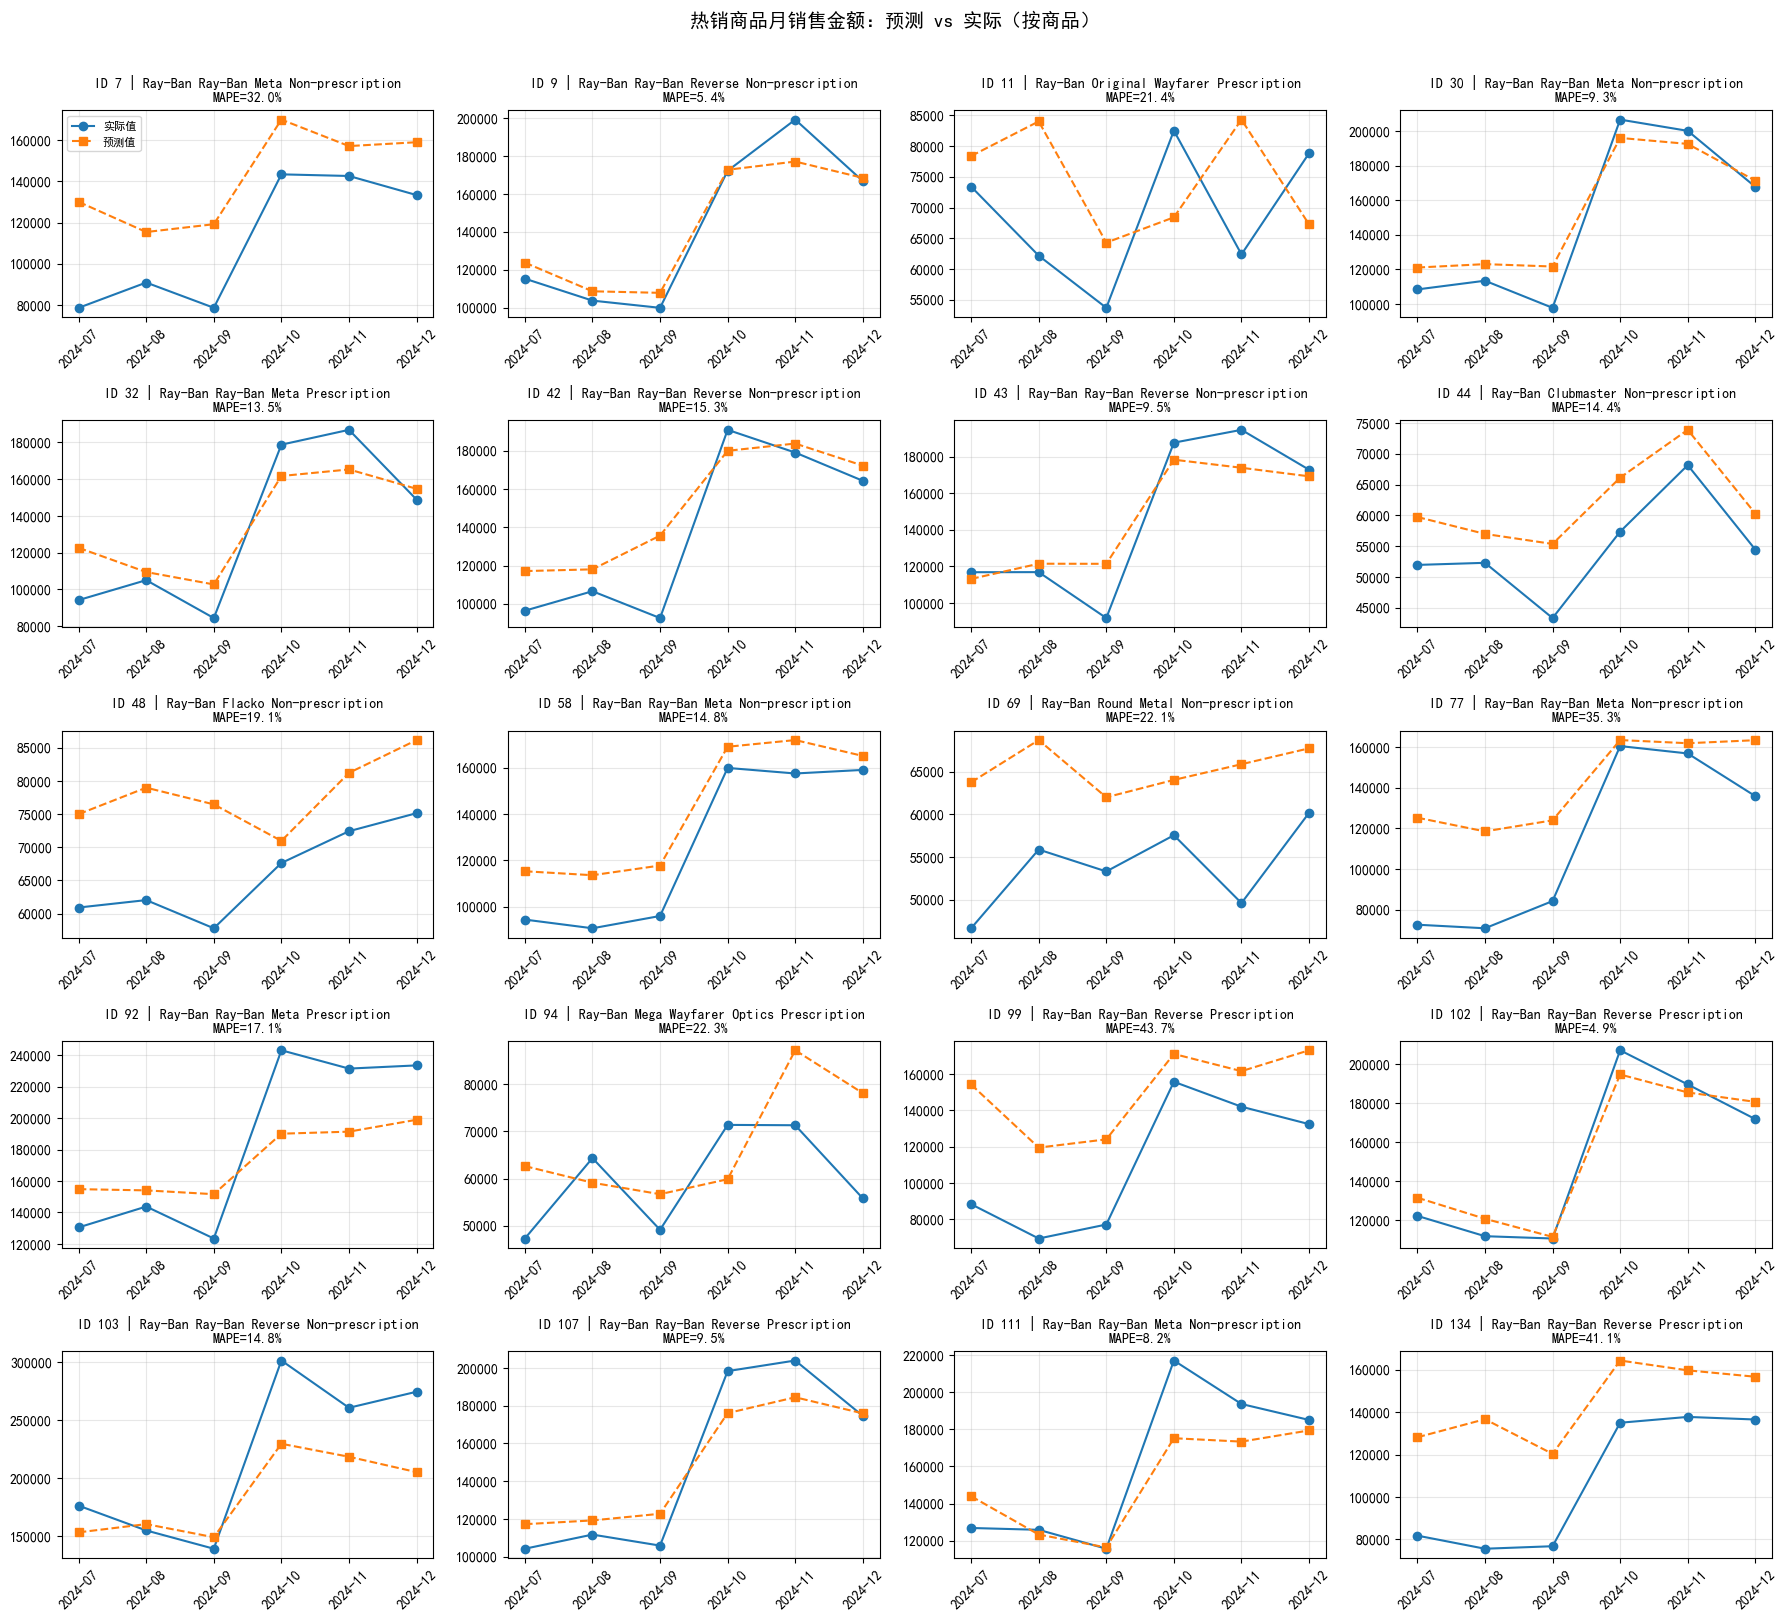

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1) 拼成一张评估表（顺序必须与 test 一致）
df_plot = test[['order_month', 'product_id', 'category']].copy()
df_plot['y_true'] = np.asarray(y_test_rev)
df_plot['y_pred'] = np.asarray(pred_final)   # 或 lgm_pred_qty_final / cat_pred_qty

# 可选：商品名
if 'df_popular' in globals() and 'product_name' in df_popular.columns:
    name_map = df_popular.set_index('product_id')['product_name'].to_dict()
else:
    name_map = {}

product_ids = sorted(df_plot['product_id'].unique())
n = len(product_ids)

# 2) 子图布局：例如 4 列
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows), sharex=False)
axes = np.array(axes).reshape(-1)

for i, pid in enumerate(product_ids):
    ax = axes[i]
    g = (
        df_plot[df_plot['product_id'] == pid]
        .sort_values('order_month')
    )
    ax.plot(g['order_month'], g['y_true'], marker='o', label='实际值')
    ax.plot(g['order_month'], g['y_pred'], marker='s', linestyle='--', label='预测值')

    title = name_map.get(pid, str(pid))
    # 单品 MAPE（避免除0）
    mape_i = np.mean(np.abs(g['y_true'] - g['y_pred']) / np.maximum(g['y_true'], 1e-6))
    ax.set_title(f'ID {pid} | {title}\nMAPE={mape_i:.1%}', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

# 去掉多余空轴
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('热销商品月销售金额：预测 vs 实际（按商品）', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

# import os
# # output_dir = "output/5-4_cat_pred_rev-figures"
# # output_dir = "output/5-4_lgm_pred_rev_final-figures"
# output_dir = "output/5-4_prophet_pred_rev-figures"

# os.makedirs(output_dir, exist_ok=True)
# fig.tight_layout()
# fig.savefig(
#     os.path.join(output_dir, "popular_product_pred_vs_actual.png"),
#     dpi=200,
#     bbox_inches="tight"
# )
# plt.show()


### data vis 2

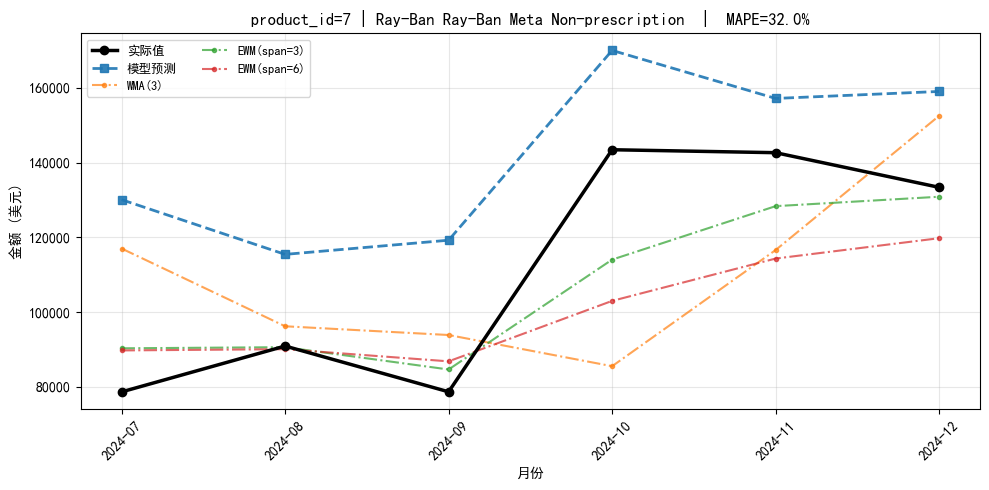

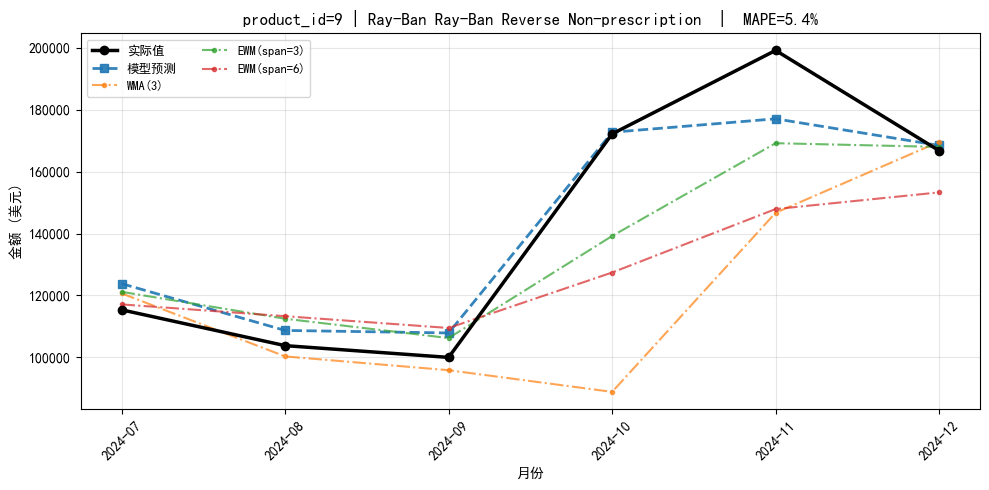

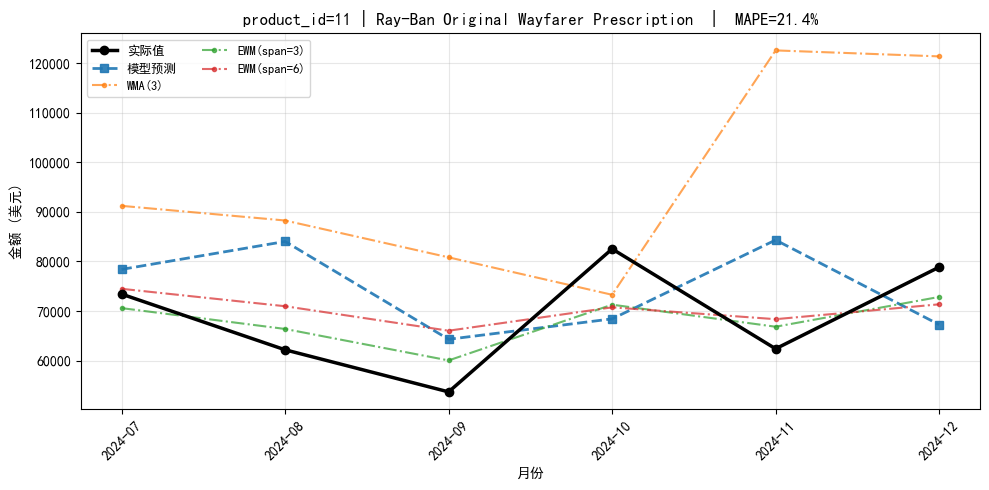

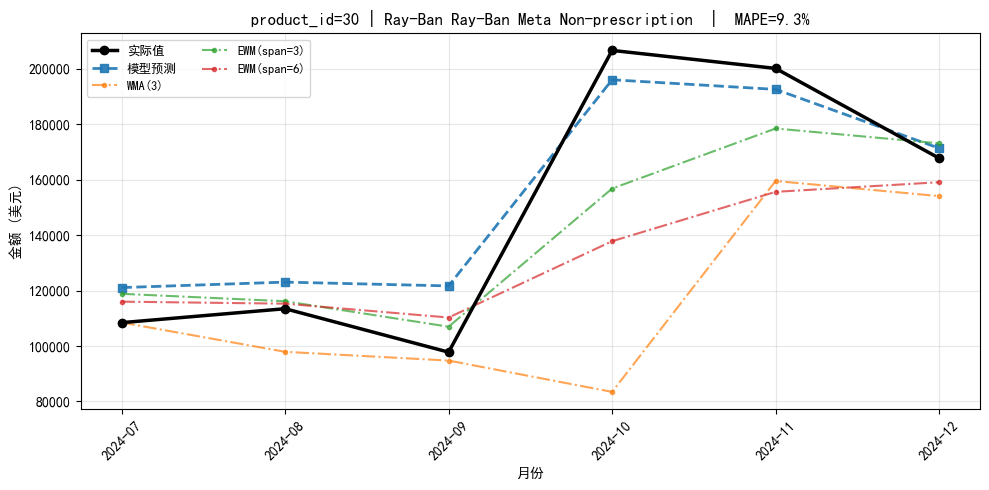

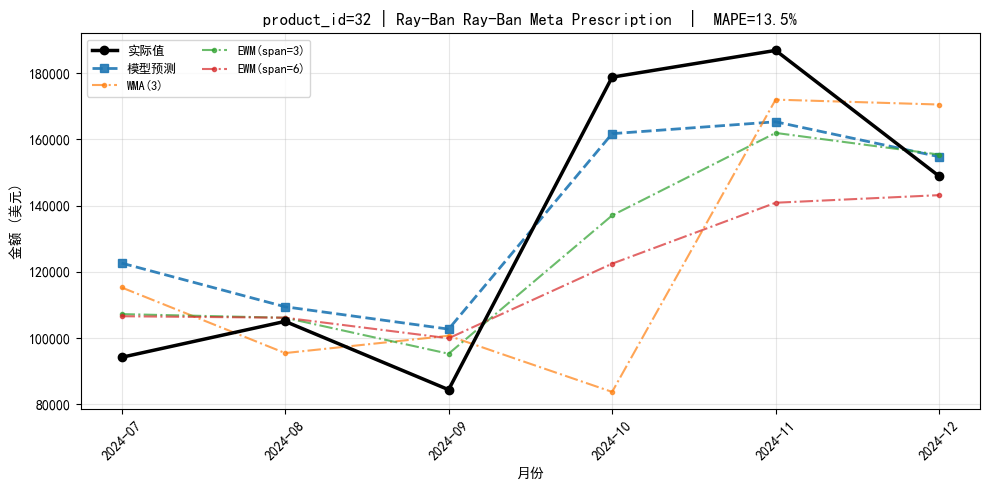

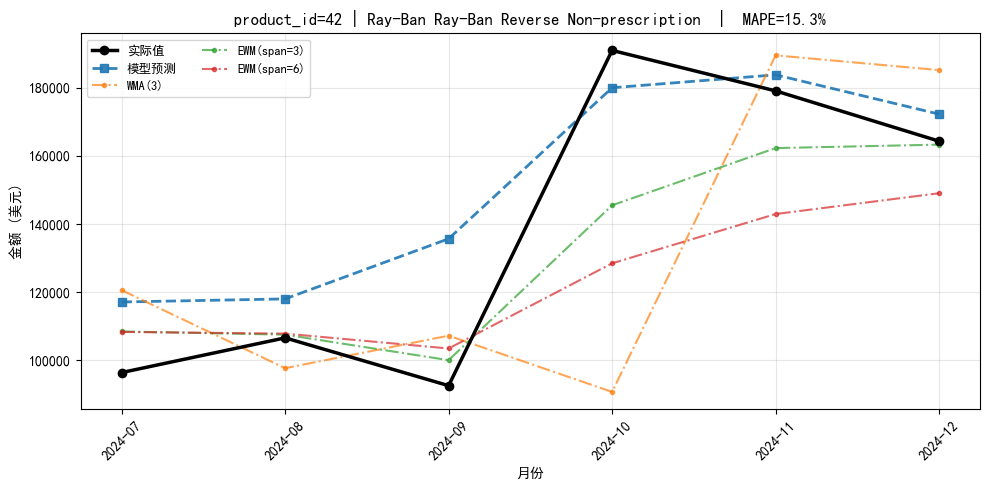

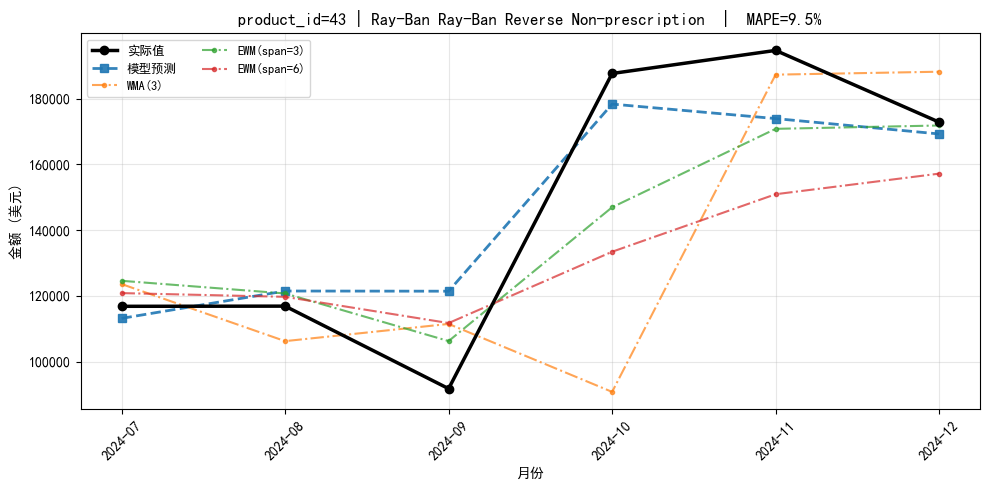

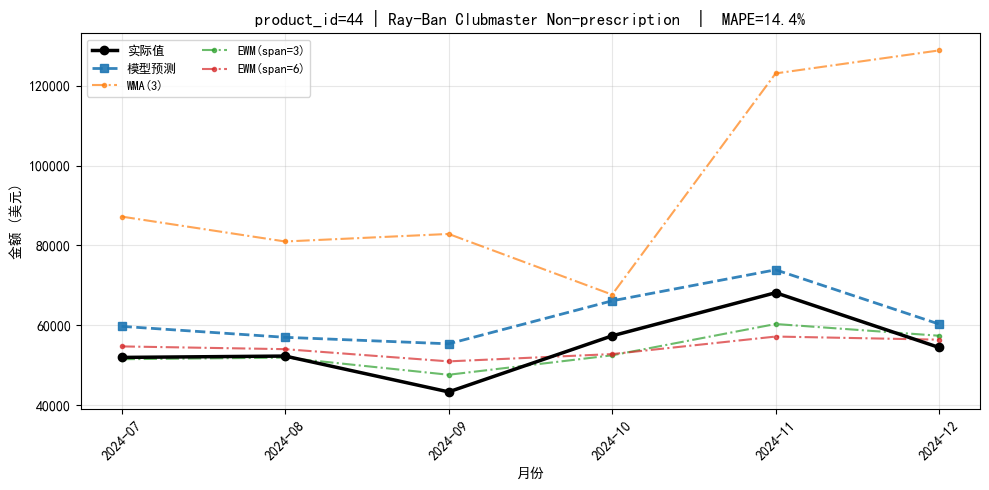

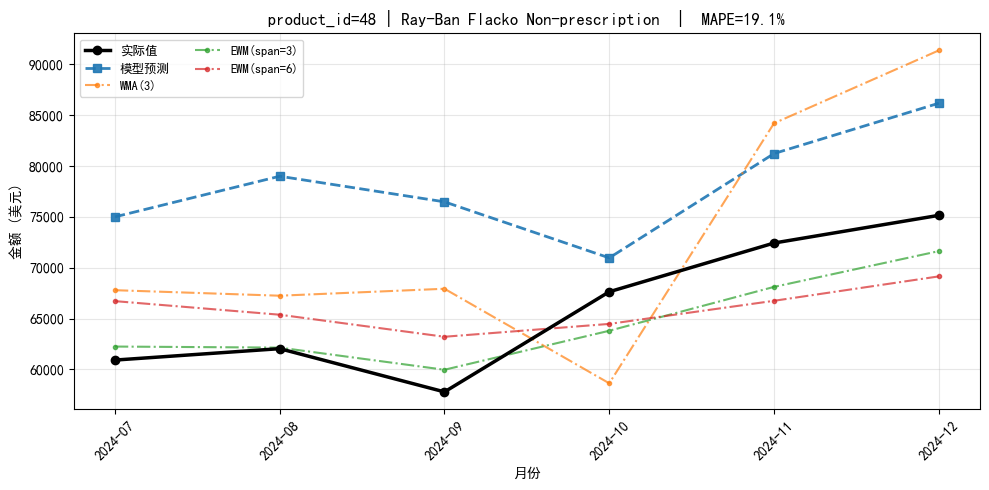

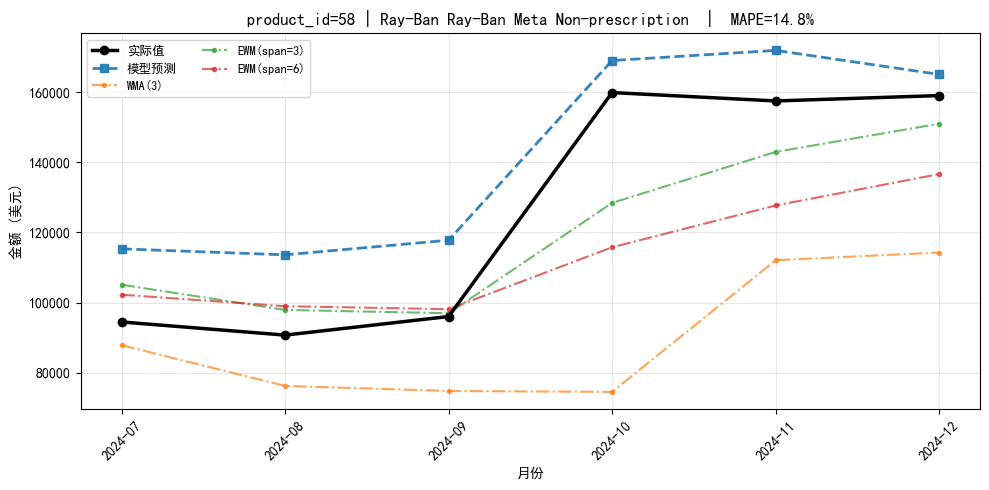

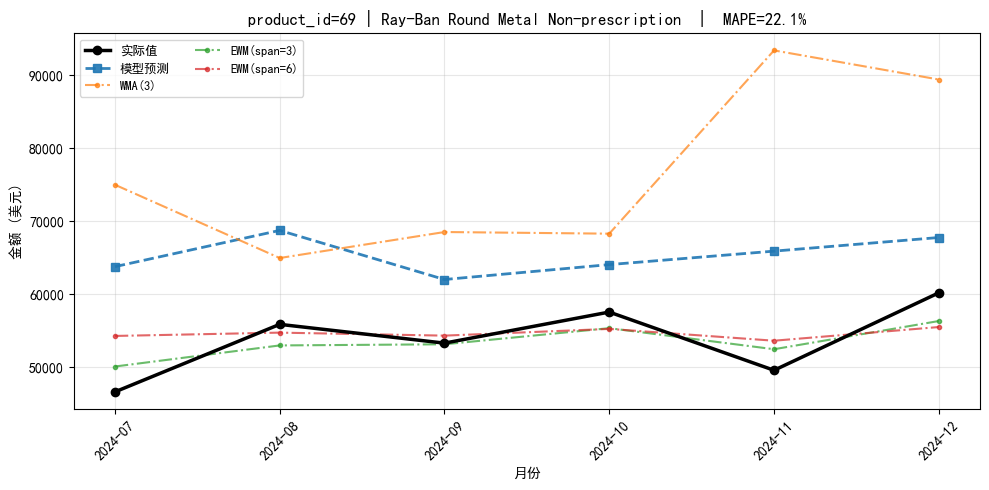

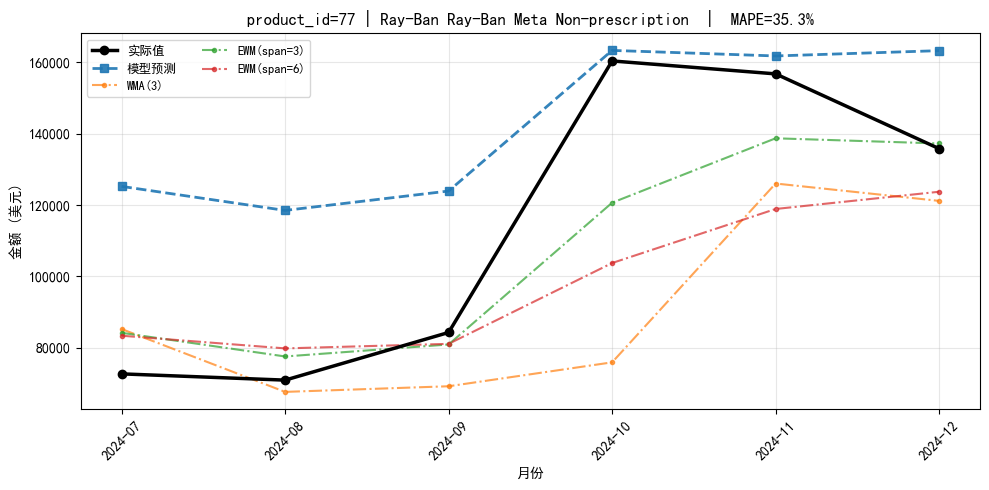

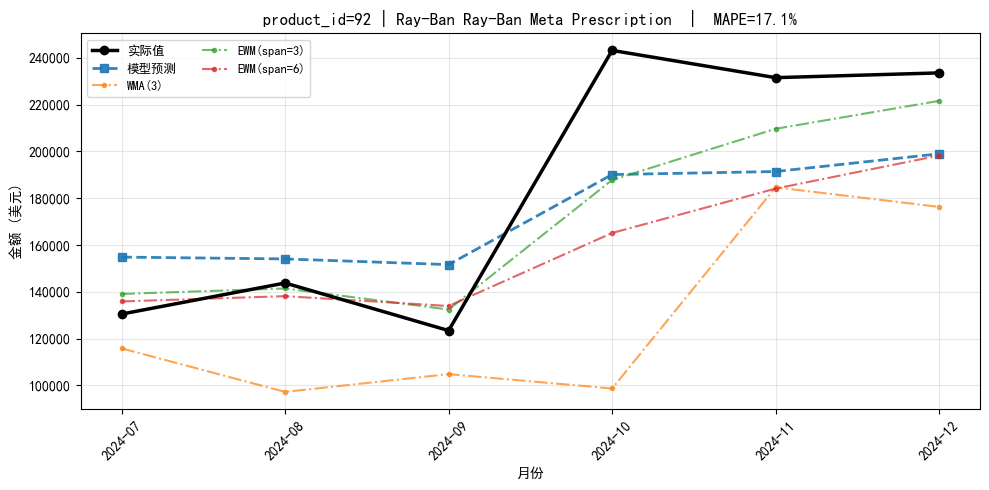

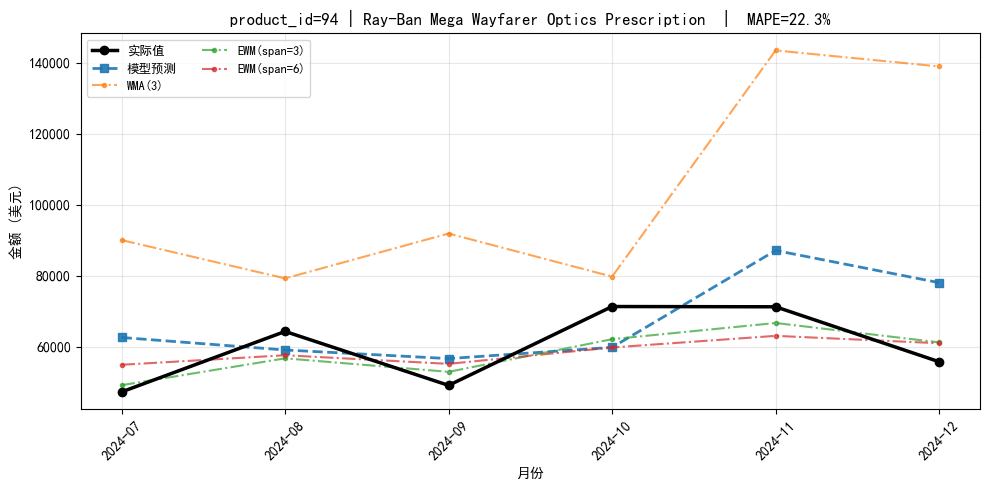

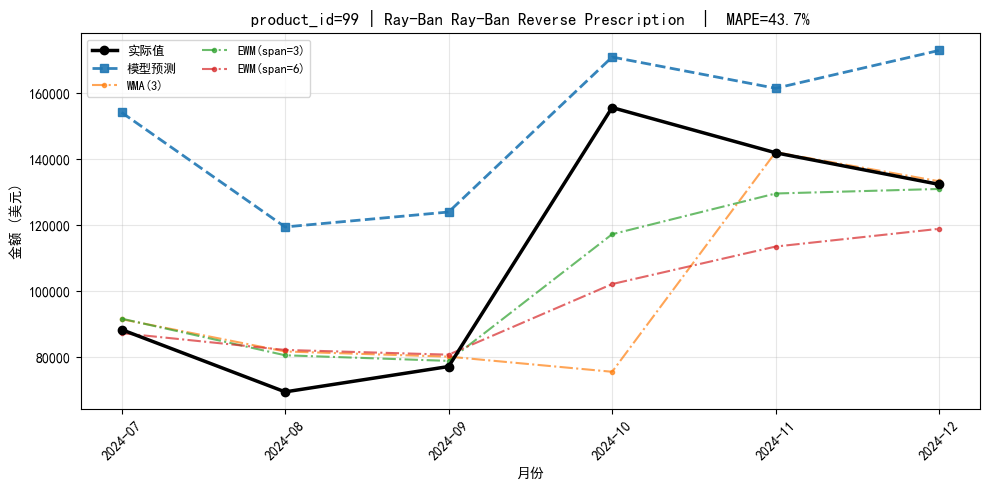

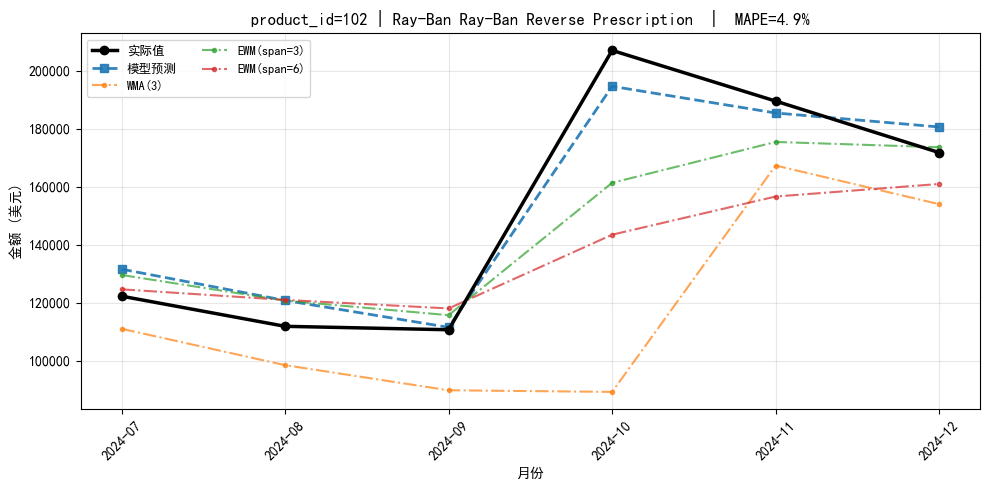

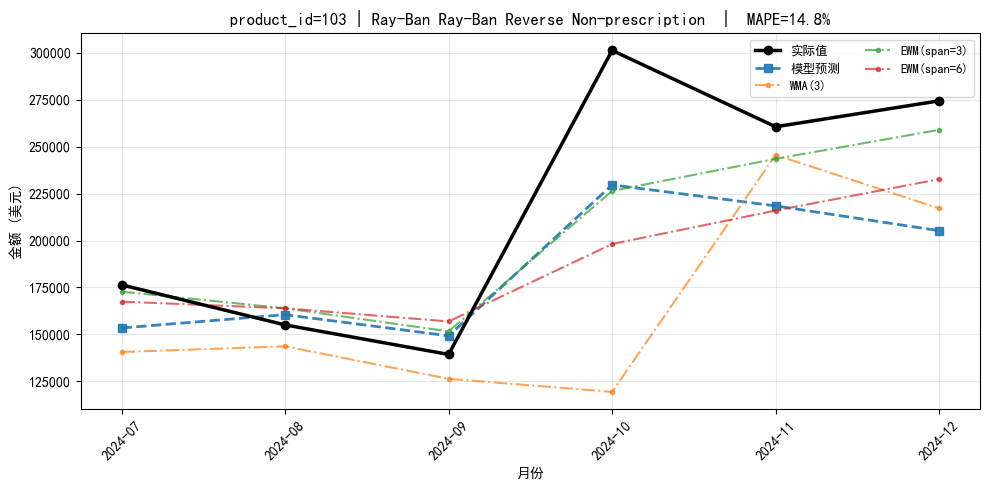

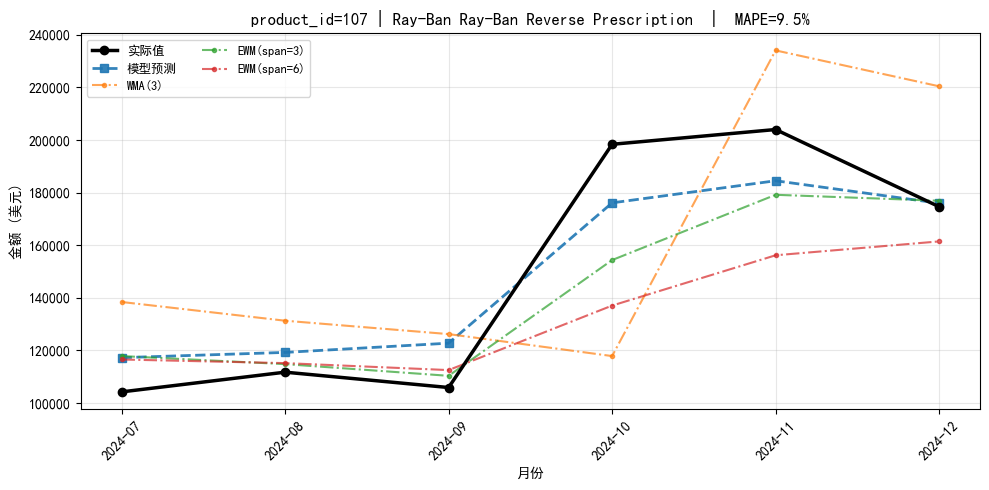

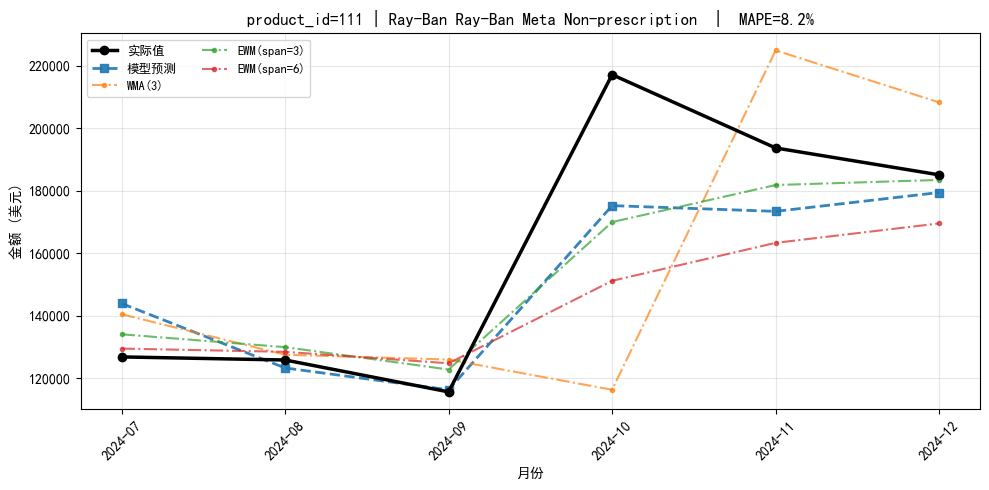

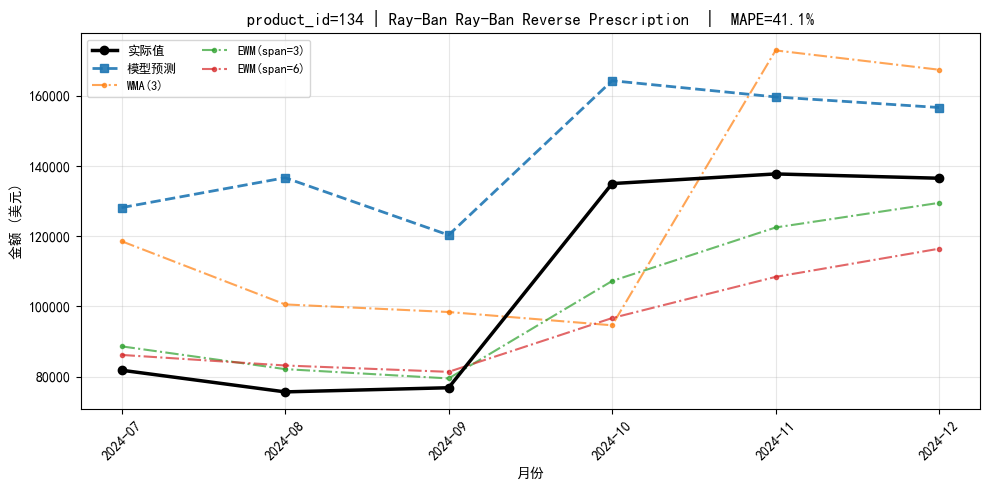

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 1) 预测 vs 真实（与 test 行顺序一致）----------
df_plot = test[['order_month', 'product_id', 'category']].copy()
df_plot['y_true'] = np.asarray(y_test_rev)
df_plot['y_pred'] = np.asarray(pred_final)  # 或 lgm_pred_qty_final / cat_pred_qty

# ---------- 2) Baseline：按 product_id + order_month 对齐 ----------
baseline_cols = [
    'order_month', 'product_id',
    'wma_3', 'ewm_3', 'ewm_6',
]
baseline_cols = [c for c in baseline_cols if c in df_timeseries_features.columns]

df_base = df_timeseries_features[baseline_cols].copy()

df_plot = df_plot.merge(df_base, on=['order_month', 'product_id'], how='left')
df_plot = df_plot.sort_values(['product_id', 'order_month']).reset_index(drop=True)

# 商品名（可选）
if 'df_popular' in globals() and 'product_name' in df_popular.columns:
    name_map = df_popular.set_index('product_id')['product_name'].to_dict()
else:
    name_map = {}

# 要画的 baseline 列（存在才画）
baseline_plot_cols = [
    c for c in ['wma_3', 'ewm_3', 'ewm_6',
                'rolling_3_month_avg_revenue', 'rolling_6_month_avg_revenue',
                'historical_mean', 'historical_median']
    if c in df_plot.columns
]

# baseline 显示名
baseline_labels = {
    'wma_3': 'WMA(3)',
    'ewm_3': 'EWM(span=3)',
    'ewm_6': 'EWM(span=6)',
    'rolling_3_month_avg_revenue': '3月滚动均值',
    'rolling_6_month_avg_revenue': '6月滚动均值',
    'historical_mean': '历史均值',
    'historical_median': '历史中位数',
}

product_ids = sorted(df_plot['product_id'].unique())

# ---------- 3) 每个产品单独一张图 ----------
for pid in product_ids:
    g = df_plot[df_plot['product_id'] == pid].sort_values('order_month')

    plt.figure(figsize=(10, 5))

    # 真实 & 预测
    plt.plot(g['order_month'], g['y_true'],
             marker='o', linewidth=2.5, color='black', label='实际值', zorder=10)
    plt.plot(g['order_month'], g['y_pred'],
             marker='s', linewidth=2, linestyle='--', label='模型预测', alpha=0.9)

    # baselines
    for col in baseline_plot_cols:
        plt.plot(
            g['order_month'], g[col],
            marker='.', linewidth=1.5, linestyle='-.',
            alpha=0.7, label=baseline_labels.get(col, col)
        )

    # 单品 MAPE
    mape_i = np.mean(
        np.abs(g['y_true'] - g['y_pred']) / np.maximum(g['y_true'].astype(float), 1e-6)
    )
    title = name_map.get(pid, '')
    title_str = f'product_id={pid}' + (f' | {title}' if title else '')
    title_str += f'  |  MAPE={mape_i:.1%}'

    plt.title(title_str, fontsize=12, fontweight='bold')
    plt.xlabel('月份')
    plt.ylabel('金额 (美元)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best', fontsize=9, ncol=2)
    plt.tight_layout()
    plt.show()


### output the actual and predict results into a file - v2

In [96]:
import os
import numpy as np
import pandas as pd

os.makedirs("output", exist_ok=True)

# =========================
# 1) 先准备输出主表
# =========================
# 这里要求 test 里至少有 product_id、order_month
assert "product_id" in test.columns, "test 中必须包含 product_id 列"
assert "order_month" in test.columns, "test 中必须包含 order_month 列"

# 2) 测试月份对应的 baseline（按销量字段）
baseline_cols = [
    "rolling_3_month_avg_revenue",
    "rolling_6_month_avg_revenue",
    "wma_3",
    "ewm_3",
    "ewm_6",
]

baseline_data_test = (
    df_timeseries_features[
        df_timeseries_features["order_month"].isin(test["order_month"].astype(str).values)
    ]
    .sort_values(["order_month", "product_id"])
    .reset_index(drop=True)
    [["order_month", "product_id"] + baseline_cols]
    .copy()
)
baseline_data_test["order_month"] = baseline_data_test["order_month"].astype(str)


# 真实值：如果你当前 test 表中本身已经是 product_month 粒度，则可以直接用 test['customer_paid_quantity']
# 如果不是，则这里用 y_test_qty 逐行对应
# 这一步的关键：先保留每一行原始记录
base_df = test[["product_id", "order_month"]].copy()
base_df["actual_monthly_revenue"] = np.asarray(y_test_rev, dtype=float)

# 预测值（按行对齐）
base_df["lightgbm_pred"] = np.asarray(lgm_pred_rev_final, dtype=float)
base_df["catboost_pred"] = np.asarray(cat_pred_rev, dtype=float)

# 校准后的值
base_df["lightgbm_pred_calibrated"] = (
    np.asarray(lgm_pred_rev_calibrated, dtype=float)
    if "lgm_pred_rev_calibrated" in locals()
    else np.asarray(lgm_pred_rev_final, dtype=float)
)
base_df["catboost_pred_calibrated"] = (
    np.asarray(cat_pred_rev_calibrated, dtype=float)
    if "cat_pred_rev_calibrated" in locals()
    else np.asarray(cat_pred_rev, dtype=float)
)


# 如果你还有 Prophet 结果
if "prophet_pred_rev" in locals():
    base_df["prophet_pred"] = np.asarray(prophet_pred_rev, dtype=float)
else:
    base_df["prophet_pred"] = np.nan

# 你的最终预测值
# 你可以换成 weighted blend / catboost / lightgbm 等
if "pred_final" in locals():
    base_df["final_pred"] = np.asarray(pred_final, dtype=float)
else:
    base_df["final_pred"] = base_df["catboost_pred"]

# =========================
# 2) 按 product_id + order_month 聚合
# =========================
agg_df = (
    base_df.groupby(["product_id", "order_month"], as_index=False)
    .agg({
        "actual_monthly_revenue": "sum",
        "lightgbm_pred": "sum",
        "catboost_pred": "sum",
        "prophet_pred": "sum",
        "lightgbm_pred_calibrated": "sum",
        "catboost_pred_calibrated": "sum",
        "final_pred": "sum"
    })
)


agg_df = agg_df.merge(
    baseline_data_test,
    on=["order_month", "product_id"],
    how="left"
)

# =========================
# 3) 计算误差指标
# =========================
agg_df["lightgbm_mae"] = np.abs(agg_df["lightgbm_pred"] - agg_df["actual_monthly_revenue"])
agg_df["lightgbm_mape"] = np.abs(
    (agg_df["lightgbm_pred"] - agg_df["actual_monthly_revenue"])
    / agg_df["actual_monthly_revenue"].replace(0, np.nan)
)

agg_df["catboost_mae"] = np.abs(agg_df["catboost_pred"] - agg_df["actual_monthly_revenue"])
agg_df["catboost_mape"] = np.abs(
    (agg_df["catboost_pred"] - agg_df["actual_monthly_revenue"])
    / agg_df["actual_monthly_revenue"].replace(0, np.nan)
)

agg_df["prophet_mae"] = np.abs(agg_df["prophet_pred"] - agg_df["actual_monthly_revenue"])
agg_df["prophet_mape"] = np.abs(
    (agg_df["prophet_pred"] - agg_df["actual_monthly_revenue"])
    / agg_df["actual_monthly_revenue"].replace(0, np.nan)
)

agg_df["final_mae"] = np.abs(agg_df["final_pred"] - agg_df["actual_monthly_revenue"])
agg_df["final_mape"] = np.abs(
    (agg_df["final_pred"] - agg_df["actual_monthly_revenue"])
    / agg_df["actual_monthly_revenue"].replace(0, np.nan)
)

# =========================
# 4) 排序
# =========================

# 重新按 month + actual 排序
df_hot_product_month = (
    agg_df
    .sort_values(["order_month", "actual_monthly_revenue"], ascending=[True, False])
    .reset_index(drop=True)
)

print(df_hot_product_month.head(20))

# =========================
# 5) 导出
# =========================
df_hot_product_month.to_parquet(
    "output/5-4-each_month_popular_product_sale_amount_prediction.parquet",
    index=False,
    engine="fastparquet"
)

print("已保存 parquet 文件: output/5-4-each_month_popular_product_sale_amount_prediction.parquet")
df_hot_product_month

    product_id order_month  actual_monthly_revenue  lightgbm_pred  \
0          103     2024-07               176399.84  171536.511690   
1           92     2024-07               130505.19  156429.339875   
2          111     2024-07               126851.37  141042.901941   
3          102     2024-07               122229.18  156043.231182   
4           43     2024-07               116816.29  140476.989448   
5            9     2024-07               115325.72  143950.142321   
6           30     2024-07               108407.39  145948.608782   
7          107     2024-07               104191.14  148715.877817   
8           42     2024-07                96359.93  134861.469453   
9           58     2024-07                94449.16  133727.214223   
10          32     2024-07                94179.81  138192.279098   
11          99     2024-07                88309.91  131397.430092   
12         134     2024-07                81790.17  126797.876224   
13           7     2024-07        

,product_id,order_month,actual_monthly_revenue,lightgbm_pred,catboost_pred,prophet_pred,lightgbm_pred_calibrated,catboost_pred_calibrated,final_pred,rolling_3_month_avg_revenue,...,ewm_3,ewm_6,lightgbm_mae,lightgbm_mape,catboost_mae,catboost_mape,prophet_mae,prophet_mape,final_mae,final_mape
0,103,2024-07,176399.84,171536.511690,153440.054278,218113.682264,171536.411615,154209.110500,153440.054278,131647.506667,...,172783.295640,167465.260563,4863.328310,0.027570,22959.785722,0.130158,41713.842264,0.236473,22959.785722,0.130158
1,92,2024-07,130505.19,156429.339875,154834.078113,176010.862933,156429.239800,155603.134335,154834.078113,99225.596667,...,139098.058224,135897.034147,25924.149875,0.198645,24328.888113,0.186421,45505.672933,0.348689,24328.888113,0.186421
2,111,2024-07,126851.37,141042.901941,143958.461443,163506.782597,141042.801866,144727.517665,143958.461443,142277.403333,...,134086.310522,129517.191166,14191.531941,0.111875,17107.091443,0.134859,36655.412597,0.288963,17107.091443,0.134859
3,102,2024-07,122229.18,156043.231182,131541.286294,153823.121645,156043.131107,132310.342516,131541.286294,95814.526667,...,129546.512015,124590.888017,33814.051182,0.276645,9312.106294,0.076186,31593.941645,0.258481,9312.106294,0.076186
4,43,2024-07,116816.29,140476.989448,113150.056036,153504.629634,140476.889373,113919.112258,113150.056036,122251.266667,...,124577.085681,120834.540521,23660.699448,0.202546,3666.233964,0.031385,36688.339634,0.314069,3666.233964,0.031385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,11,2024-12,78841.01,74256.280497,67252.668700,86666.409140,74256.180421,68021.724922,67252.668700,134735.626667,...,72833.400845,71346.028836,4584.729503,0.058152,11588.341300,0.146984,7825.399140,0.099255,11588.341300,0.146984
116,48,2024-12,75151.04,77480.952207,86180.033917,84721.448175,77480.852132,86949.090139,86180.033917,111744.946667,...,71632.902874,69148.248925,2329.912207,0.031003,11028.993917,0.146758,9570.408175,0.127349,11028.993917,0.146758
117,69,2024-12,60187.58,61018.513840,67757.839706,63500.969365,61018.413765,68526.895928,67757.839706,93186.883333,...,56328.593313,55506.022767,830.933840,0.013806,7570.259706,0.125778,3313.389365,0.055051,7570.259706,0.125778
118,94,2024-12,55807.65,74434.863447,78072.668415,71688.811484,74434.763371,78841.724637,78072.668415,153192.980000,...,61263.633709,61014.504643,18627.213447,0.333775,22265.018415,0.398960,15881.161484,0.284570,22265.018415,0.398960


In [97]:
df_hot_product_month['product_id'].unique()
df_hot_product_month['product_id'].nunique()

20

In [98]:
df_hot_product_month.columns

Index(['product_id', 'order_month', 'actual_monthly_revenue', 'lightgbm_pred',
       'catboost_pred', 'prophet_pred', 'lightgbm_pred_calibrated',
       'catboost_pred_calibrated', 'final_pred', 'rolling_3_month_avg_revenue',
       'rolling_6_month_avg_revenue', 'wma_3', 'ewm_3', 'ewm_6',
       'lightgbm_mae', 'lightgbm_mape', 'catboost_mae', 'catboost_mape',
       'prophet_mae', 'prophet_mape', 'final_mae', 'final_mape'],
      dtype='object')

In [99]:
import gc
gc.collect()

20

In [37]:
# 关闭数据库连接
engine.dispose()